# Heavy Equipment Selling Price Prediction

**Goal:** predict the selling price (`TargetValue`) of used heavy equipment.
**Metric:** RMSLE, which is the RMSE of `log1p(TargetValue)`, so every model is trained and scored in log space.

**Pipeline:** load data → data audit → EDA → outlier handling → cleaning → feature engineering → preprocessing →
5 baseline models → tuning of 3 models → feature importance → weighted ensemble → submission.

In [1]:
import os, re, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

SEED = 42            # fixed seed -> same split / sampling / model init on every run (reproducibility only)
DATA_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"

# random-search budgets (lower these for a quick dry run)
N_ITER_HGB, N_ITER_LGBM, N_ITER_XGB = 100, 100, 20

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


def barh_labeled(series, title, xlabel, fmt="%.0f", figsize=(10, 6)):
    """Horizontal bar chart WITH value labels (the review asked for readable charts)."""
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(series.index.astype(str), series.values)
    ax.bar_label(bars, fmt=fmt, padding=3)
    ax.invert_yaxis()
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.margins(x=0.15)
    plt.tight_layout(); plt.show()


def grid_axes(n, ncols=3, row_height=3.6):
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, row_height * nrows))
    axes = np.ravel(axes)
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Load Data

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
metadata = pd.read_csv(f"{DATA_DIR}/metadata.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

### Metadata
`metadata.csv` explains the anonymous columns (`col1 … col25`). It is loaded here and the descriptions are
used later when we plot / drop / rank features, so no column is treated as a black box.

In [3]:
print("metadata shape:", metadata.shape)
print("metadata columns:", metadata.columns.tolist())
display(metadata.head(10))

# Auto-detect which metadata column holds the description and which holds the feature name.
# (If the printout above shows different headers, set name_col / desc_col by hand.)
def _pick(cols, keys, default):
    for k in keys:
        for c in cols:
            if k in c.lower():
                return c
    return default

desc_col = _pick(metadata.columns, ["desc", "meaning", "definition", "detail"], metadata.columns[-1])
name_col = _pick([c for c in metadata.columns if c != desc_col], ["feature", "column", "name", "field"],
                 [c for c in metadata.columns if c != desc_col][0])

col_desc = dict(zip(metadata[name_col].astype(str), metadata[desc_col].astype(str)))
def describe_col(c):
    return col_desc.get(c, "(no description in metadata)")

print(f"name column = '{name_col}', description column = '{desc_col}', {len(col_desc)} descriptions loaded")

metadata shape: (50, 2)
metadata columns: ['Variable', 'Rephrased Description']


,Variable,Rephrased Description
0,TransactionID,A unique serial number assigned to each indivi...
1,TargetValue,"The financial amount of the transaction, denom..."
2,AssetID,The internal tracking number assigned to a spe...
3,ProductConfigID,A system-generated code representing the techn...
4,DataOriginCode,A code indicating the specific software or pla...
5,VendorPartnerID,The unique ID of the external entity or third-...
6,TransactionDate,The official calendar date when the entry was ...
7,RegionCode,The specific geographic area or legal jurisdic...
8,ManufactureYear,The year the asset was originally produced.
9,OperationalHoursMeter,The lifetime total of active run-time or work ...


name column = 'Variable', description column = 'Rephrased Description', 50 descriptions loaded


# First Look Of The Data

In [4]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Extended,Powershuttle,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Florida,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Texas,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
print("train shape :", train.shape)
print("test shape :", test.shape)

train shape : (138701, 50)
test shape : (15000, 49)


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [7]:
# random_state fixes WHICH 10 rows are drawn, so the output is identical every time the notebook is re-run.
# It has no effect on the model; it only makes this inspection reproducible.
train.sample(10, random_state=SEED)

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
87556,2264916,97500.0,1202885,24297,CEA153,MNT,1999,0.0,NaN,2010-12-01,D8RLRC,D8,R,NaN,LRC,Large,"Track Type Tractor, Dozer - 260.0 + Horsepower",Missouri,TTT,Track Type Tractors,NaN,EROPS w AC,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,Multi Shank,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi U,None or Unspecified,NaN,NaN
63136,1709476,31500.0,1216746,15947,ADI149,MPF,1999,NaN,NaN,2008-09-28,456BZX,456,B,NaN,ZX,Medium,Wheel Loader - 175.0 to 200.0 Horsepower,New Jersey,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
83354,2245491,57500.0,1078295,3835,CEA153,UJF,2002,0.0,NaN,2010-05-05,950G,950,G,NaN,NaN,Medium,Wheel Loader - 175.0 to 200.0 Horsepower,Arizona,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
134099,4408622,17000.0,1194413,20101,IHB189,UJF,2003,2713.0,Low,2011-09-22,TB145,TB145,NaN,NaN,NaN,Mini,"Hydraulic Excavator, Track - 4.0 to 5.0 Metric...",Georgia,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
87324,2263973,19000.0,834967,13835,CEA153,MNJ,2002,0.0,NaN,2009-11-14,D5CIIIXL,D5,C,III,XL,NaN,"Track Type Tractor, Dozer - 85.0 to 105.0 Hors...",Connecticut,TTT,Track Type Tractors,NaN,OROPS,NaN,NaN,NaN,Hydrostatic,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAT,None or Unspecified,NaN,NaN
74388,1818808,22000.0,1136592,9865,ADI149,SQU,1001,NaN,NaN,1997-03-19,MG400,MG400,NaN,NaN,NaN,NaN,Motorgrader - 145.0 to 170.0 Horsepower,Arkansas,MG,Motor Graders,No,OROPS,NaN,NaN,NaN,None or Unspecified,NaN,None or Unspecified,None or Unspecified,None or Unspecified,No,Base + 1 Function,None or Unspecified,None or Unspecified,Yes,Sideshift & Tip,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14043,1211971,49000.0,1017229,3368,ACH138,GTX,1001,1573.0,Low,2012-02-24,12G,12,G,NaN,NaN,NaN,Motorgrader - 130.0 to 145.0 Horsepower,Alabama,MG,Motor Graders,No,EROPS,NaN,NaN,NaN,None or Unspecified,NaN,None or Unspecified,14',None or Unspecified,No,Base + 1 Function,None or Unspecified,None or Unspecified,Yes,None or Unspecified,"15.5""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111816,2456417,26000.0,1786972,5903,CEA153,UJF,1999,0.0,NaN,2008-12-06,L90C,L90,C,NaN,NaN,Medium,Wheel Loader - 135.0 to 150.0 Horsepower,Texas,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,20.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
133398,4390024,75000.0,1050891,18217,IHB189,UJF,2005,6180.0,High,2010-11-10,G720B,G720,B,NaN,NaN,NaN,Motorgrader - 200.0 + Horsepower,Michigan,MG,Motor Graders,No,EROPS w AC,NaN,NaN,NaN,Powershift,NaN,Yes,14',None or Unspecified,No,Base + 1 Function,Yes,None or Unspecified,None or Unspecified,None or Unspecified,"14""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95518,2312010,37500.0,1697035,13416,CEA153,UNKNOWN_VENDOR,2003,0.0,NaN,2008-08-25,314CCR,314,C,NaN,CR,Small,"Hydraulic Excavator, Track - 14

# Data Identification

In [8]:
# Parse dates first, otherwise TransactionDate would be mis-counted as a categorical (object) column.
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])
test["TransactionDate"] = pd.to_datetime(test["TransactionDate"])

identifier_cols = [c for c in ["TransactionID", "AssetID", "ProductConfigID"] if c in train.columns]

numeric_cols = train.select_dtypes(include="number").columns.tolist()
categorical_cols = train.select_dtypes(include="object").columns.tolist()
datetime_cols = train.select_dtypes(include="datetime").columns.tolist()

# numeric columns that are real measurements (no IDs, no target) -> used for stats / plots / outliers
feature_num_cols = [c for c in numeric_cols if c not in identifier_cols + ["TargetValue"]]

print(f"Total columns       : {train.shape[1]}")
print(f"Numeric columns     : {len(numeric_cols)}  -> {numeric_cols}")
print(f"Categorical (object): {len(categorical_cols)}")
print(f"Datetime columns    : {len(datetime_cols)}  -> {datetime_cols}")
print(f"Check: {len(numeric_cols)} + {len(categorical_cols)} + {len(datetime_cols)} = "
      f"{len(numeric_cols) + len(categorical_cols) + len(datetime_cols)}")
print(f"\nIdentifier-like columns (not real measurements): {identifier_cols}")
print(f"Numeric feature columns used for analysis      : {feature_num_cols}")

Total columns       : 50
Numeric columns     : 6  -> ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter']
Categorical (object): 43
Datetime columns    : 1  -> ['TransactionDate']
Check: 6 + 43 + 1 = 50

Identifier-like columns (not real measurements): ['TransactionID', 'AssetID', 'ProductConfigID']
Numeric feature columns used for analysis      : ['ManufactureYear', 'OperationalHoursMeter']


In [9]:
# TransactionDate range (train and test) + nulls
for name, df in [("train", train), ("test", test)]:
    print(f"{name}: {df['TransactionDate'].min().date()} -> {df['TransactionDate'].max().date()}  "
          f"| null dates: {df['TransactionDate'].isnull().sum()}")

train: 1990-01-31 -> 2013-04-28  | null dates: 0
test: 1990-01-31 -> 2013-04-28  | null dates: 0


In [10]:
# ManufactureYear range check: look for impossible values, not just min/max
print(train["ManufactureYear"].describe())

implausible = train.loc[train["ManufactureYear"] < 1900, "ManufactureYear"].value_counts()
print("\nImplausible ManufactureYear values (< 1900) and their counts:")
print(implausible)
print(f"-> {implausible.sum()} rows ({implausible.sum() / len(train):.2%} of train) carry a placeholder year")

valid = train["ManufactureYear"] >= 1900
sold_before_built = (train.loc[valid, "TransactionDate"].dt.year < train.loc[valid, "ManufactureYear"]).sum()
print(f"Rows sold before they were manufactured (impossible): {sold_before_built}")
print(f"Null ManufactureYear: {train['ManufactureYear'].isnull().sum()}")

count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
max        2015.000000
Name: ManufactureYear, dtype: float64

Implausible ManufactureYear values (< 1900) and their counts:
ManufactureYear
1001    14719
Name: count, dtype: int64
-> 14719 rows (10.61% of train) carry a placeholder year
Rows sold before they were manufactured (impossible): 7
Null ManufactureYear: 0


# Duplicate rows
A full-row duplicate check is almost guaranteed to return 0 because `TransactionID` / `AssetID` are unique, so
we also check duplicates **ignoring the ID columns** (and optionally the target). That answers the real question:
*was the same machine configuration sold more than once with identical attributes?*

In [11]:
id_like = [c for c in ["TransactionID", "AssetID"] if c in train.columns]
feat_only = [c for c in train.columns if c not in id_like + ["TargetValue"]]

print("full-row duplicates                     :", train.duplicated().sum())
print("duplicates ignoring IDs and target      :", train.duplicated(subset=feat_only).sum())
print("duplicates ignoring IDs (target equal)  :", train.duplicated(subset=feat_only + ["TargetValue"]).sum())

full-row duplicates                     : 0
duplicates ignoring IDs and target      : 3838
duplicates ignoring IDs (target equal)  : 1310


# Missing Values

In [12]:
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(train) * 100).round(2)      # percentage missing per column

missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]

# attach the metadata description so the anonymous colN columns are interpretable
display(missing_df.assign(description=[describe_col(c) for c in missing_df.index]))

,missing_count,missing_pct,description
col19,138635,99.95,The rate of fluid flow through the system by v...
col18,138635,99.95,The system used for traction and contact with ...
col5,128320,92.52,The status or type of the engine’s air intake/...
col4,128320,92.52,The specific layout or reach of the extension ...
col27,123742,89.21,The specific design or category of the attache...
col28,123742,89.21,The configuration of the operator's directiona...
col29,119829,86.39,The type of differential used for power distri...
col30,119829,86.39,The primary interface used by the operator for...
col13,115296,83.13,Details on accessories used for finishing or s...
col14,115296,83.13,The logic and hardware used to control machine...


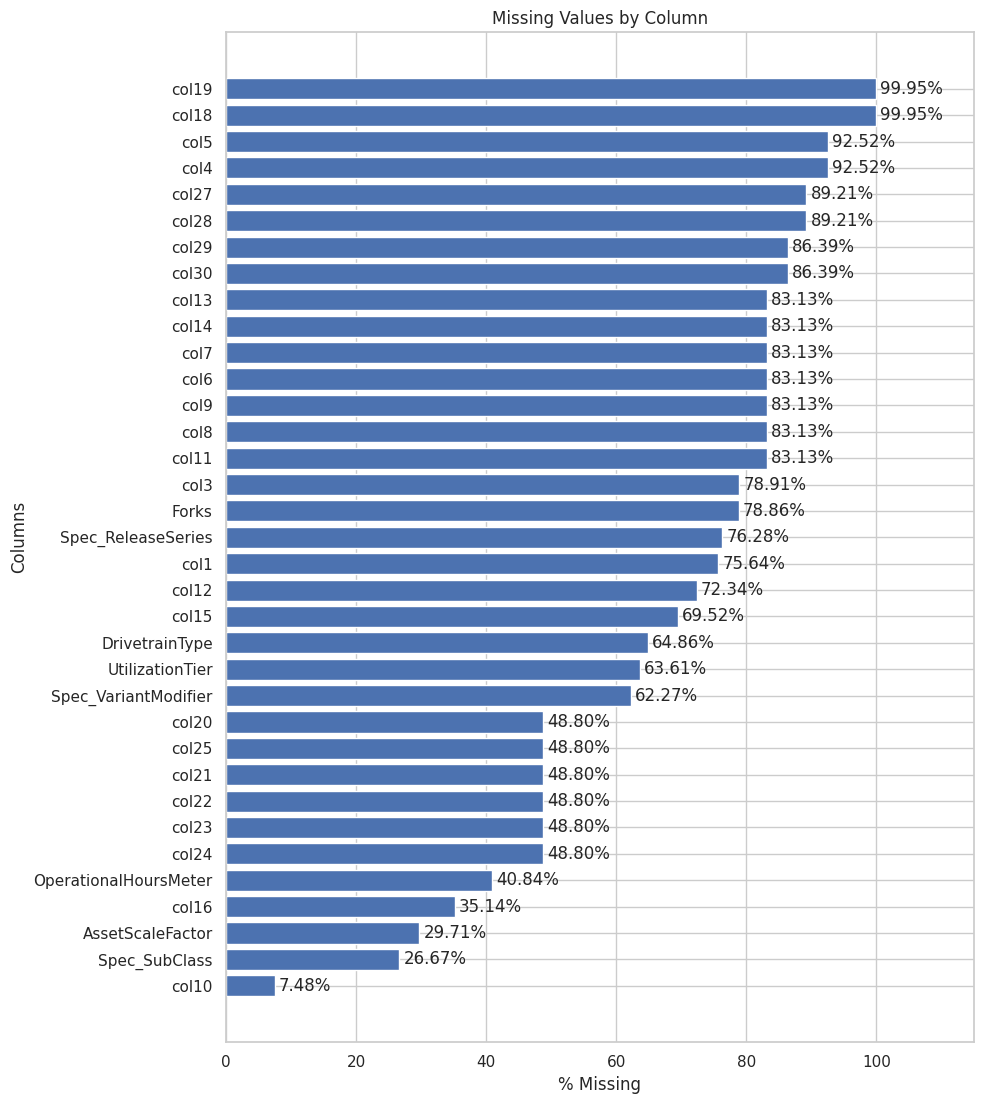

In [13]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(missing_df))))
bars = ax.barh(missing_df.index, missing_df["missing_pct"])
ax.bar_label(bars, fmt="%.2f%%", padding=3)          # data labels: exact % is readable now
ax.invert_yaxis()
ax.set_xlim(0, 115)
ax.set_xlabel("% Missing"); ax.set_ylabel("Columns"); ax.set_title("Missing Values by Column")
plt.tight_layout(); plt.show()

**How missing data is handled later**
* `> 95 %` missing → no usable signal → **dropped** (col18, col19).
* Other columns → keep, add a `<col>_was_missing` flag (missingness itself can be informative), and let the model deal
  with the gap: tree models use NaN natively; models that cannot (Gradient Boosting, Ridge) get imputation inside their pipeline.

# Skewness and Kurtosis of Numeric Columns

In [14]:
# skewness  > 1 or < -1  -> strongly skewed -> consider a log transform
# pandas .kurtosis() is EXCESS kurtosis: a normal distribution = 0
#   excess kurtosis > 0 -> heavier tails than normal -> more extreme outliers than expected
skew_kurtosis = pd.DataFrame({
    "skewness": train[feature_num_cols + ["TargetValue"]].skew(),
    "excess_kurtosis": train[feature_num_cols + ["TargetValue"]].kurtosis(),
}).sort_values("skewness", ascending=False)

display(skew_kurtosis)
print("Strongly skewed (|skew| > 1):", skew_kurtosis.index[skew_kurtosis["skewness"].abs() > 1].tolist())

,skewness,excess_kurtosis
OperationalHoursMeter,33.282248,1434.496143
TargetValue,0.969996,0.423906
ManufactureYear,-2.554133,4.531367


Strongly skewed (|skew| > 1): ['OperationalHoursMeter', 'ManufactureYear']


# Cardinality of Category Columns

,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_VariantModifier,Spec_ReleaseSeries,FunctionalClassification,RegionCode,VendorPartnerID,col22,col21,col15,col10,col27,DrivetrainType,DataOriginCode,col7,AssetScaleFactor,InventoryGroupDescription,InventoryGroupCategory,col28,col1,col12,UtilizationTier,col3,col8,col23,CabinType,col25,col24,col29,col14,col16,col4,Forks,col5,col11,col9,col6,col13,col20,col19,col18,col30
n_unique,3505,1249,147,132,113,65,53,31,27,18,15,11,9,8,6,6,6,6,6,5,4,4,3,3,3,3,3,3,3,3,3,3,2,2,2,2,2,2,2,2,2,2,2


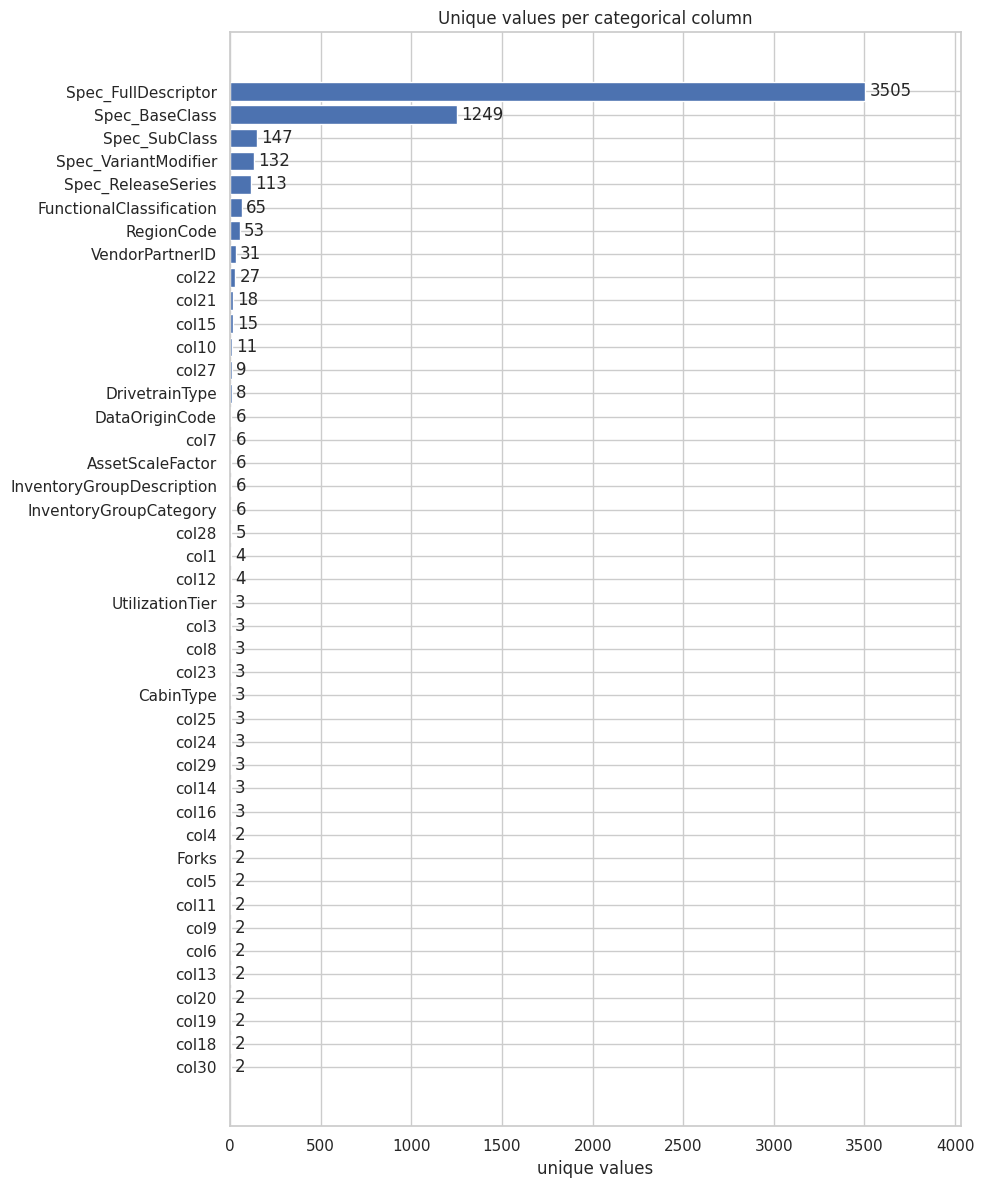

In [15]:
# cardinality -> decides the encoding strategy later
#   low cardinality  (<= 50 unique)  -> ordinal / one-hot
#   high cardinality (>  50 unique)  -> target encoding
cardinality = pd.Series({c: train[c].nunique() for c in categorical_cols}).sort_values(ascending=False)
display(cardinality.to_frame("n_unique").T)

barh_labeled(cardinality, "Unique values per categorical column", "unique values",
             fmt="%d", figsize=(10, max(5, 0.28 * len(cardinality))))

# Descriptive Statistics

In [16]:
desc = train[feature_num_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
desc["mean/median"] = desc["mean"] / desc["50%"].replace(0, np.nan)    # >> 1 -> right skew
desc["max/p99"] = desc["max"] / desc["99%"].replace(0, np.nan)          # >> 1 -> extreme tail
display(desc)

print("Mean >> median (right-skewed, favour median imputation / log):",
      desc.index[desc["mean/median"] > 1.5].tolist())
print("Max far above the 99th percentile (extreme outliers)          :",
      desc.index[desc["max/p99"] > 3].tolist())
print("Columns with negative minimum (check validity)                 :",
      desc.index[desc["min"] < 0].tolist())

,count,mean,std,min,1%,50%,99%,max,mean/median,max/p99
ManufactureYear,138701.0,1891.640853,306.992001,1001.0,1001.0,1998.0,2008.00,2015.0,0.946767,1.003486
OperationalHoursMeter,82058.0,4553.718943,27922.044850,0.0,0.0,1620.0,25796.01,1729600.0,2.810938,67.049129


Mean >> median (right-skewed, favour median imputation / log): ['OperationalHoursMeter']
Max far above the 99th percentile (extreme outliers)          : ['OperationalHoursMeter']
Columns with negative minimum (check validity)                 : []


**What the descriptive statistics tell us and how it drives the pipeline**
* *Mean vs median* – where the mean is far above the median the feature is right-skewed, so we **impute with the median**
  (the mean is dragged by outliers) and add log-transformed versions.
* *Max vs 99th percentile* – a max far beyond p99 signals extreme outliers (e.g. `OperationalHoursMeter`) → these are **clipped** (IQR rule).
* *Min values* – impossible / placeholder values (e.g. year 1001) were found this way and are cleaned before modelling.
* *Count* – a count below the row total confirms missingness, handled with flags + native NaN / imputation.
* `TransactionID` is only an identifier, so its statistics carry no information and it is excluded from modelling.

In [17]:
obj_desc = train.describe(include="object").T

obj_desc["top_share"] = (
    pd.to_numeric(obj_desc["freq"]) / pd.to_numeric(obj_desc["count"])).round(3)

display(obj_desc)  #shows a nicely formatted table.

print(
    "Near-constant categorical columns (top value > 95 %):",
    obj_desc.index[obj_desc["top_share"] > 0.95].tolist()
)

,count,unique,top,freq,top_share
DataOriginCode,138701,6,ADI149,59541,0.429
VendorPartnerID,138701,31,UJF,67828,0.489
UtilizationTier,50475,3,Medium,24588,0.487
Spec_FullDescriptor,138701,3505,140G,3751,0.027
Spec_BaseClass,138701,1249,12,5702,0.041
Spec_SubClass,101716,147,G,17381,0.171
Spec_ReleaseSeries,32896,113,II,8425,0.256
Spec_VariantModifier,52332,132,L,14496,0.277
AssetScaleFactor,97491,6,Large / Medium,39222,0.402
FunctionalClassification,138701,65,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",11158,0.080


Near-constant categorical columns (top value > 95 %): ['col5', 'col6', 'col19', 'col29', 'col30']


# EDA

### Target variable distribution

**Why transform the target?** We never change the *answer*: predictions are converted back with `expm1`, so the submission is in
original price units. The transform only changes the *scale the model learns on*. The competition metric is RMSLE, which is exactly
RMSE on `log1p(TargetValue)`, so training on the log scale directly optimises the metric and stops a few very expensive machines
from dominating the loss. The orange/blue **curve** on the histograms is a **KDE (Kernel Density Estimate)**: a smoothed estimate of
the distribution drawn over the bars.

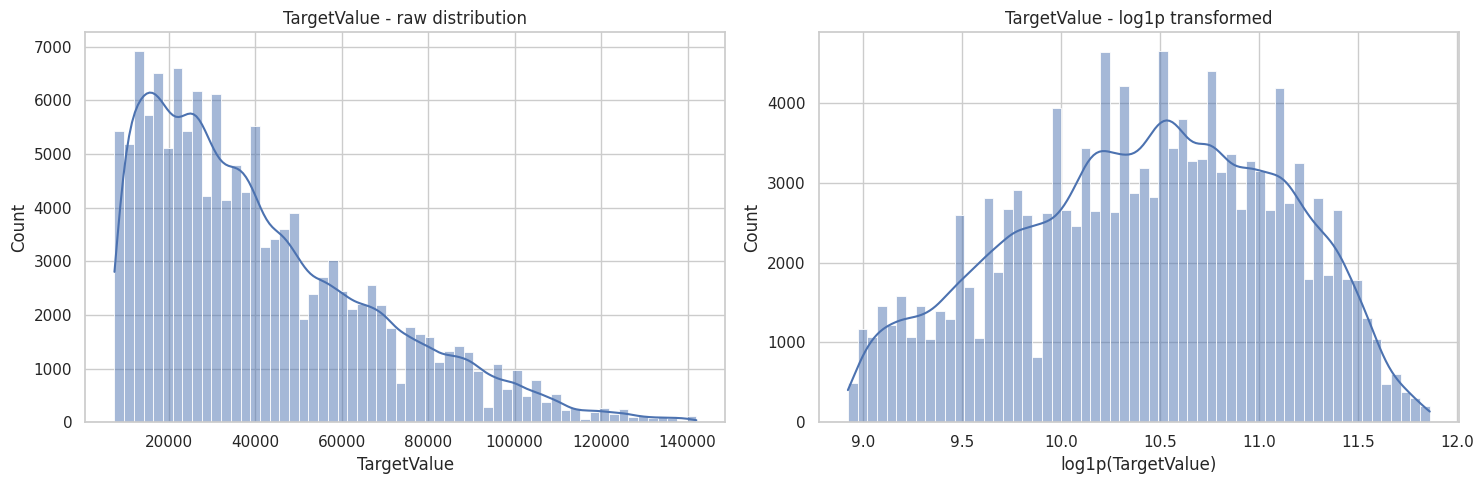

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(train["TargetValue"], kde=True, bins=60, ax=axes[0])
axes[0].set_title("TargetValue - raw distribution")
axes[0].set_xlabel("TargetValue")

sns.histplot(np.log1p(train["TargetValue"]), kde=True, bins=60, ax=axes[1])
axes[1].set_title("TargetValue - log1p transformed")
axes[1].set_xlabel("log1p(TargetValue)")
plt.tight_layout(); plt.show()

In [19]:
# is the log transform worth it? (closer to 0 skew = more symmetric)
raw_skew = abs(train["TargetValue"].skew())
log_skew = abs(np.log1p(train["TargetValue"]).skew())
use_log_target = log_skew < raw_skew

print(f"Raw skewness  : {raw_skew:.3f}")
print(f"Log1p skewness: {log_skew:.3f}")
print(f"Use log target: {use_log_target}")

Raw skewness  : 0.970
Log1p skewness: 0.198
Use log target: True


### Target Variable Boxplot --> Outlier detection

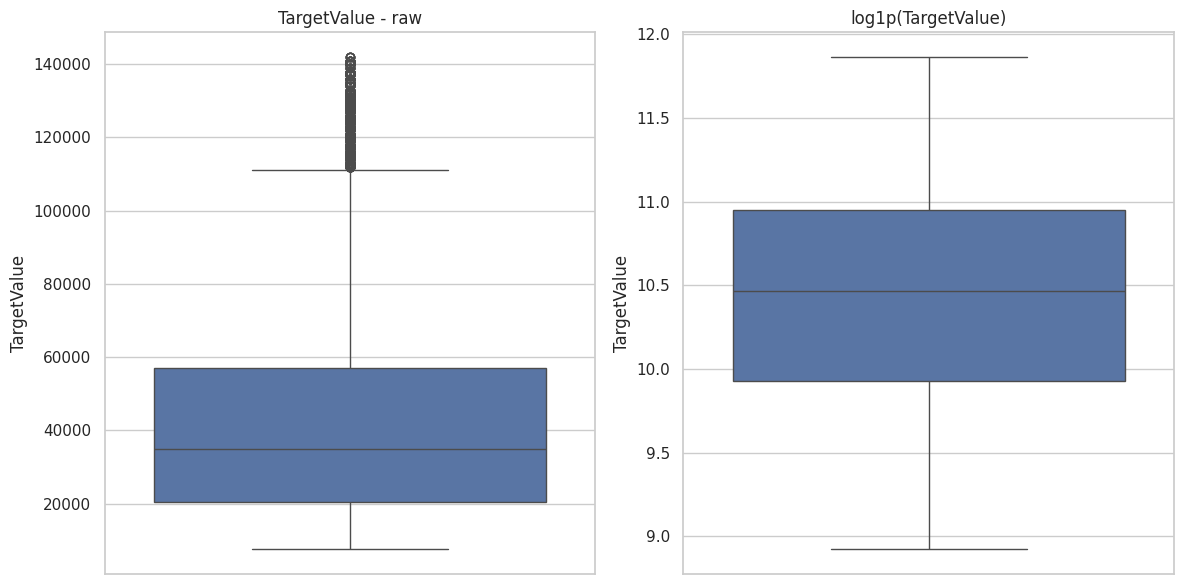

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=train, y="TargetValue", ax=axes[0]);                      axes[0].set_title("TargetValue - raw")
sns.boxplot(y=np.log1p(train["TargetValue"]), ax=axes[1]);                 axes[1].set_title("log1p(TargetValue)")
plt.tight_layout(); plt.show()

### Univariate Distribution

**Distribution plot for all numeric features** (identifiers excluded; `AssetID` is investigated separately below)

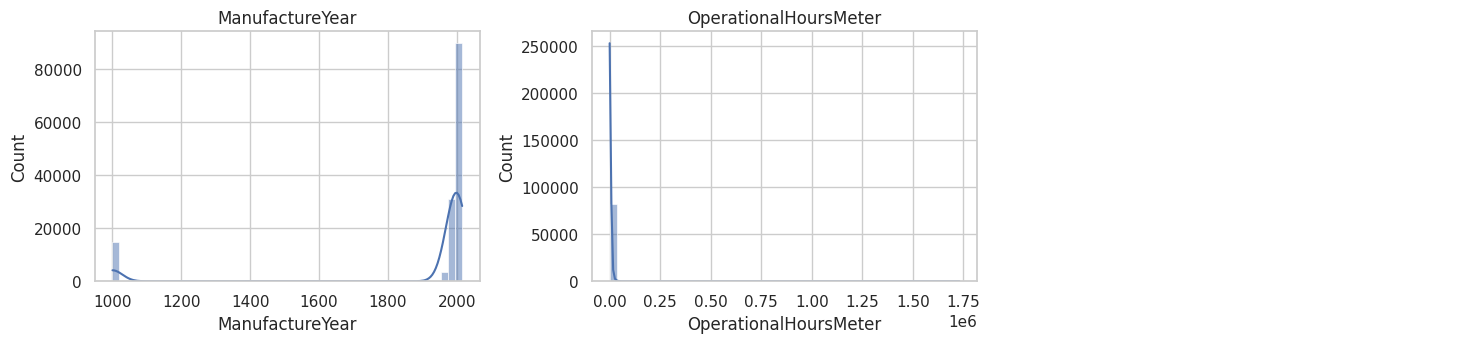

In [21]:
fig, axes = grid_axes(len(feature_num_cols))
for ax, col in zip(axes, feature_num_cols):
    sns.histplot(train[col].dropna(), kde=True, bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

### Identifier investigation
`AssetID` showed peaks and gaps in its histogram. Before throwing an identifier away we check whether it hides information:
does it repeat (same machine sold more than once)? does it overlap between train and test? does its order follow time?

In [22]:
print("Rows                 :", len(train))
for c in ["TransactionID", "AssetID", "ProductConfigID"]:
    if c in train.columns:
        print(f"{c:16s} unique = {train[c].nunique():>7}  ({train[c].nunique() / len(train):.1%} of rows)")

if "AssetID" in train.columns:
    vc = train["AssetID"].value_counts()
    print(f"\nAssetIDs that appear more than once in train : {(vc > 1).sum()}")
    print(f"Share of test AssetIDs also present in train  : {test['AssetID'].isin(train['AssetID']).mean():.1%}")

    by_year = (train.assign(year=train["TransactionDate"].dt.year)
                    .groupby("year")["AssetID"].agg(["min", "median", "max"]))
    display(by_year.head(8))
    print("Spearman corr  AssetID vs log target   :",
          round(train["AssetID"].corr(np.log1p(train["TargetValue"]), method="spearman"), 4))
    print("Spearman corr  AssetID vs sale date    :",
          round(train["AssetID"].corr(train["TransactionDate"].astype("int64"), method="spearman"), 4))

Rows                 : 138701
TransactionID    unique =  138701  (100.0% of rows)
AssetID          unique =  120111  (86.6% of rows)
ProductConfigID  unique =    3594  (2.6% of rows)

AssetIDs that appear more than once in train : 12857
Share of test AssetIDs also present in train  : 23.3%


,min,median,max
year,,,
1990,16514,1288076.0,1555844
1991,3228,1267042.5,1555768
1992,36070,1260510.0,1558172
1993,13807,1290815.5,1556059
1994,23056,1282893.0,1556622
1995,594,1282847.5,1558165
1996,1627,1274450.5,1558109
1997,2915,1284645.5,1557959


Spearman corr  AssetID vs log target   : -0.2198
Spearman corr  AssetID vs sale date    : 0.1492


*Reading the output:* if `AssetID` is (almost) unique per row and has ~0 correlation with price, it is an arbitrary key and is dropped.
If a high share of test AssetIDs also appear in train, the same machine reappears and **per-asset history would be a strong feature**
(listed under *Next steps* at the end of the notebook).

### Feature Frequency

In [23]:
low_card_eda = [c for c in categorical_cols if train[c].nunique() <= 20]
print(f"{len(low_card_eda)} categorical columns with <= 20 unique values:")
print(low_card_eda)

34 categorical columns with <= 20 unique values:
['DataOriginCode', 'UtilizationTier', 'AssetScaleFactor', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


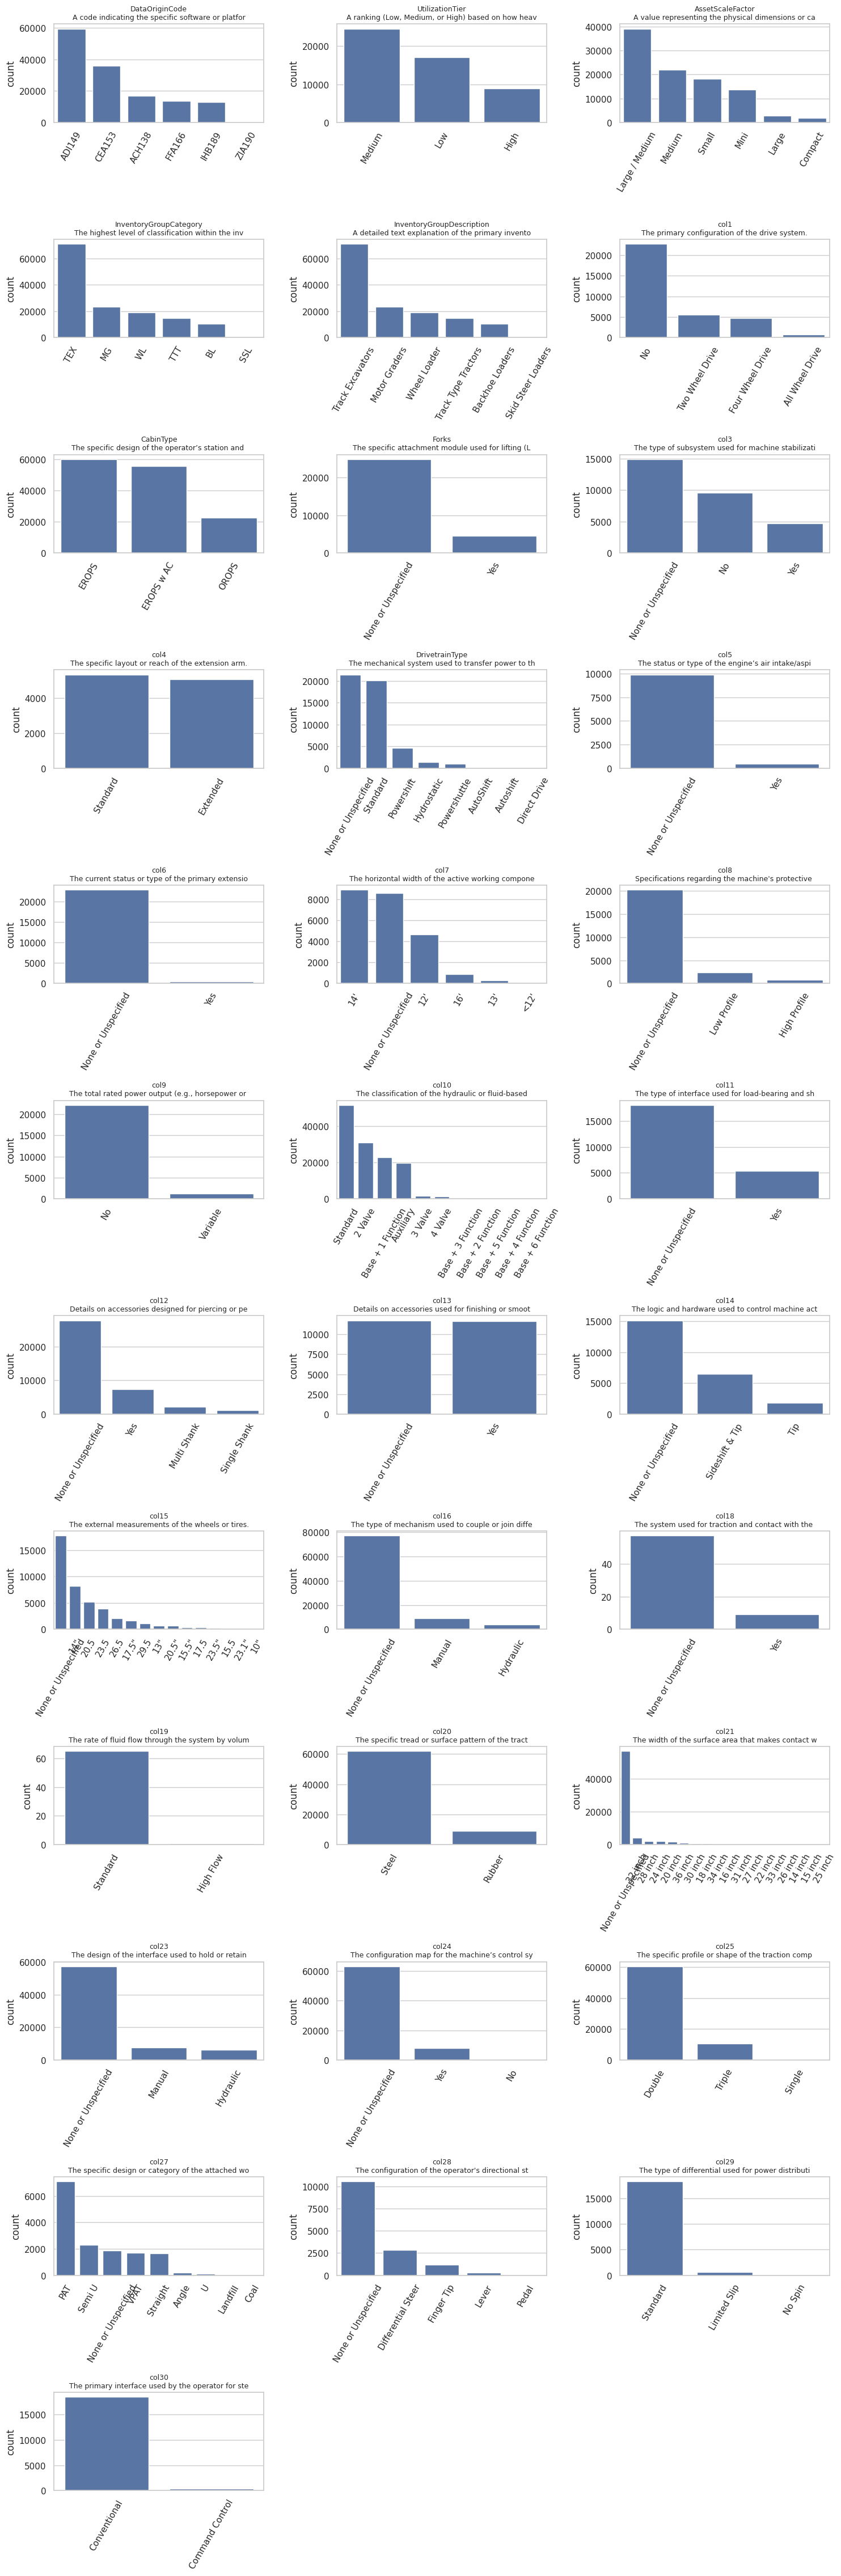

In [24]:
# count plots show how balanced / imbalanced each category is (title = metadata description)
fig, axes = grid_axes(len(low_card_eda), ncols=3, row_height=3.8)
for ax, col in zip(axes, low_card_eda):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, ax=ax)
    ax.set_title(f"{col}\n{describe_col(col)[:50]}", fontsize=9)
    ax.tick_params(axis="x", rotation=60); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### Bivariate Analysis

**Numeric features vs target.** We plot against `log1p(TargetValue)` (the scale the model learns on) and quantify each relationship with
two correlations:
* **Pearson** – strength of a *linear* relationship (sensitive to outliers).
* **Spearman** – strength of any *monotonic* relationship (rank based; robust to outliers and to non-linearity).

If |Spearman| is clearly larger than |Pearson|, the relationship is monotonic but curved.

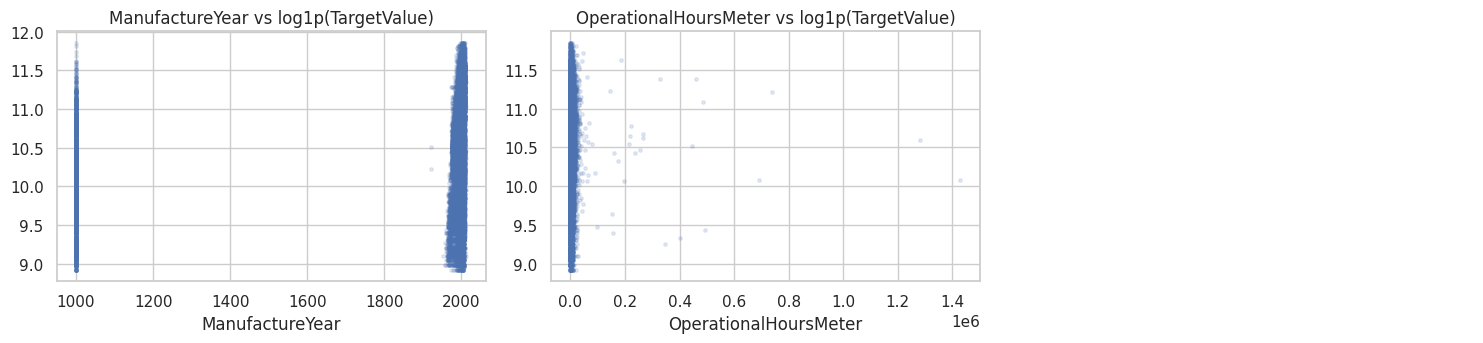

,pearson,spearman
ManufactureYear,0.234,0.322
OperationalHoursMeter,0.005,0.042


In [25]:
y_log_full = np.log1p(train["TargetValue"])
scatter_sample = train.sample(min(20000, len(train)), random_state=SEED)

fig, axes = grid_axes(len(feature_num_cols))
for ax, col in zip(axes, feature_num_cols):
    ax.scatter(scatter_sample[col], np.log1p(scatter_sample["TargetValue"]), alpha=0.15, s=6)
    ax.set_title(f"{col} vs log1p(TargetValue)"); ax.set_xlabel(col)
plt.tight_layout(); plt.show()

corr_tbl = pd.DataFrame({
    "pearson":  train[feature_num_cols].corrwith(y_log_full),
    "spearman": train[feature_num_cols].corrwith(y_log_full, method="spearman"),
})
corr_tbl["abs_spearman"] = corr_tbl["spearman"].abs()
display(corr_tbl.sort_values("abs_spearman", ascending=False).drop(columns="abs_spearman").round(3))

**Categorical features vs target** (boxplots of log price per category, sorted by median; only columns with <= 30 categories are readable)

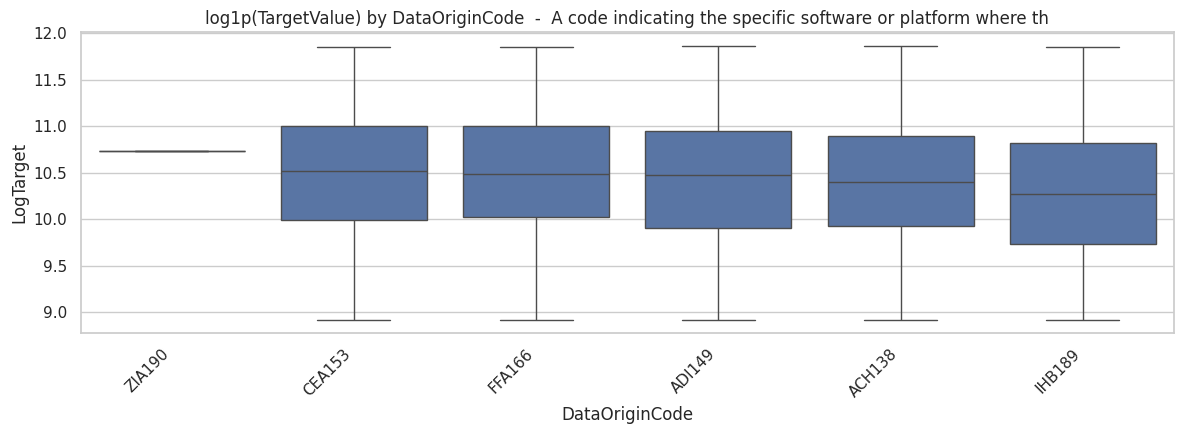

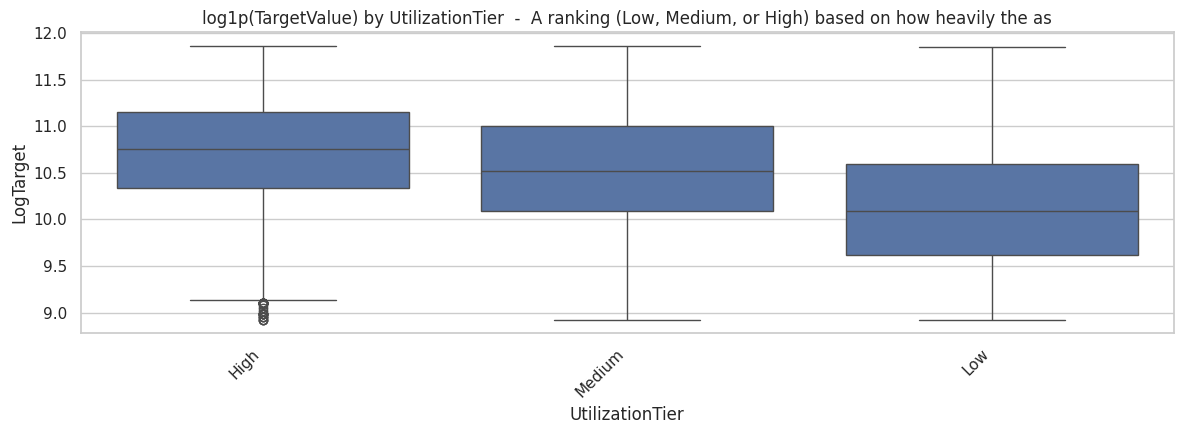

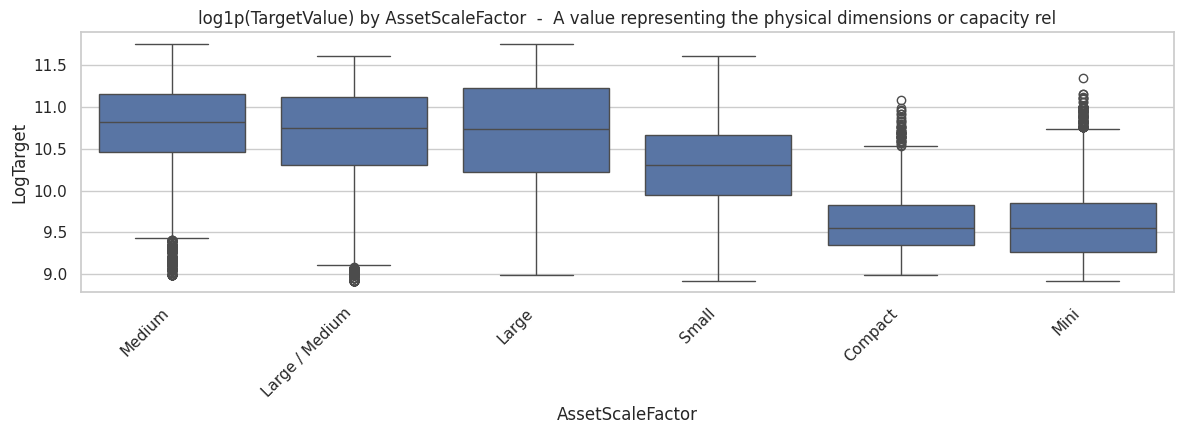

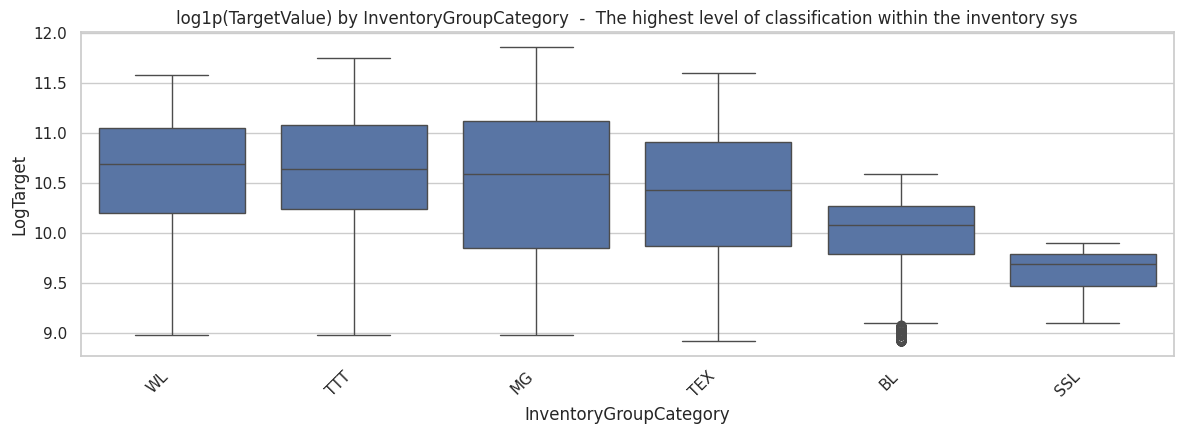

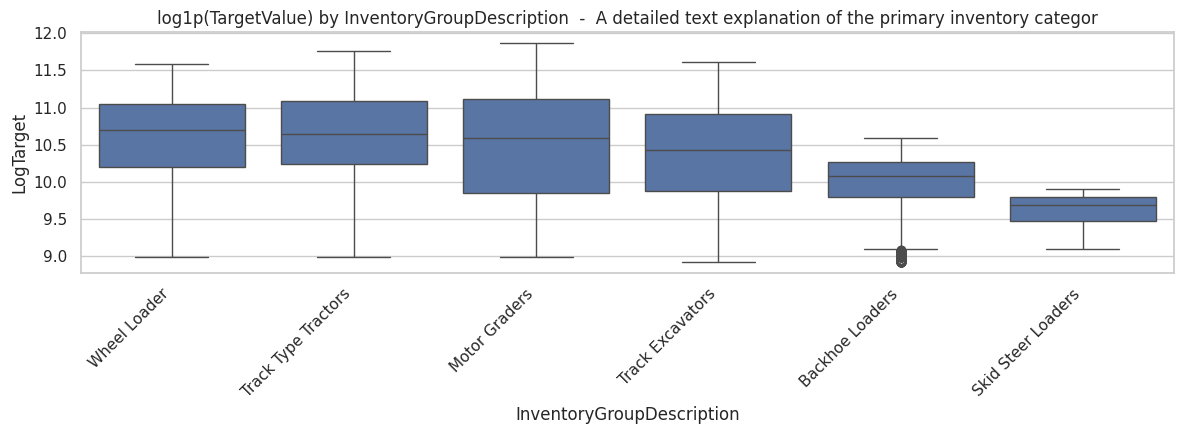

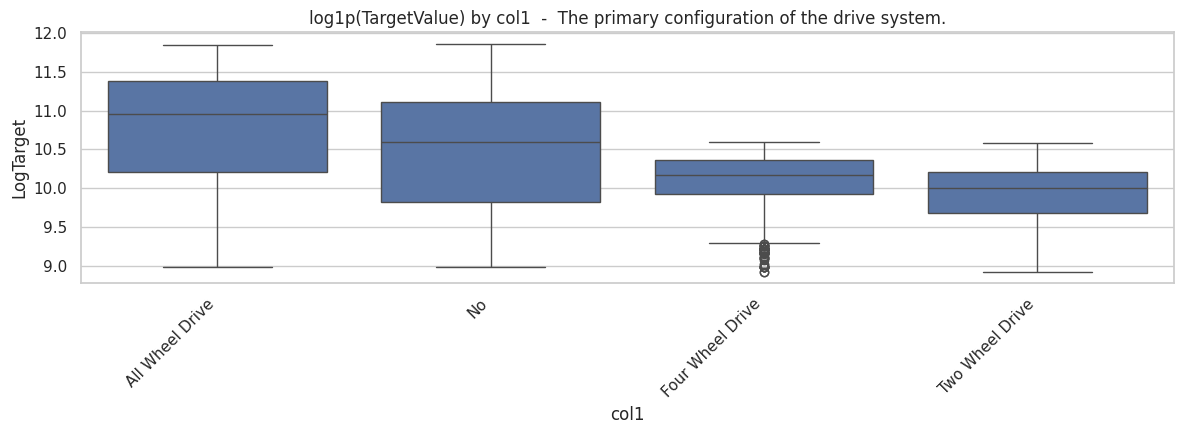

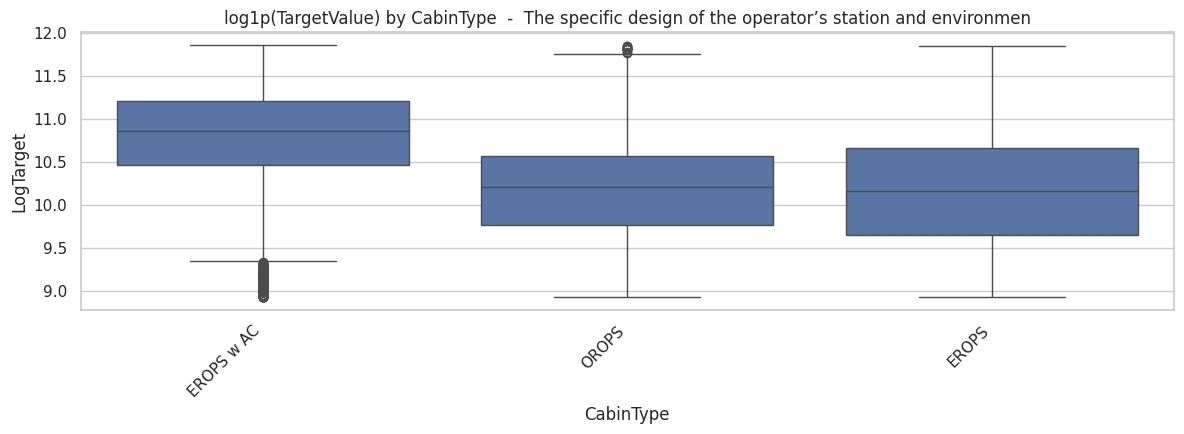

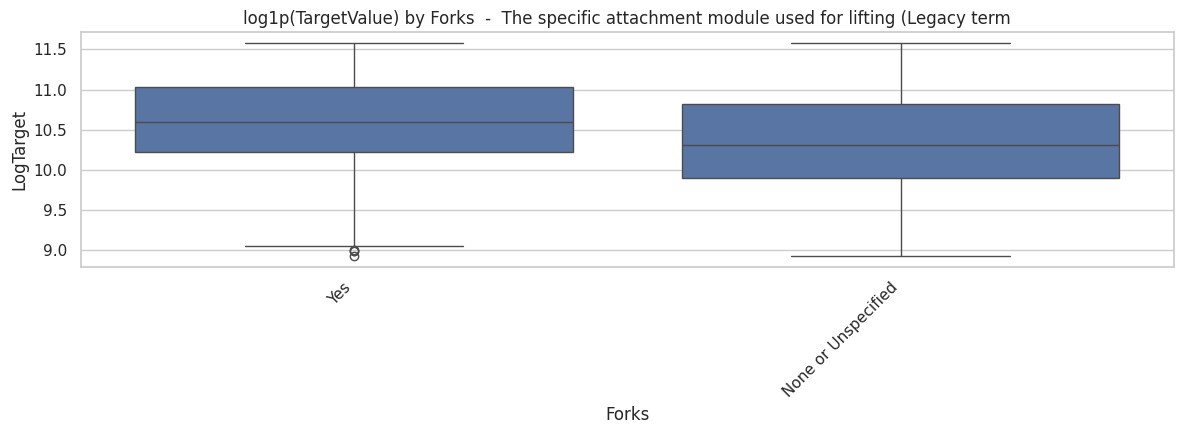

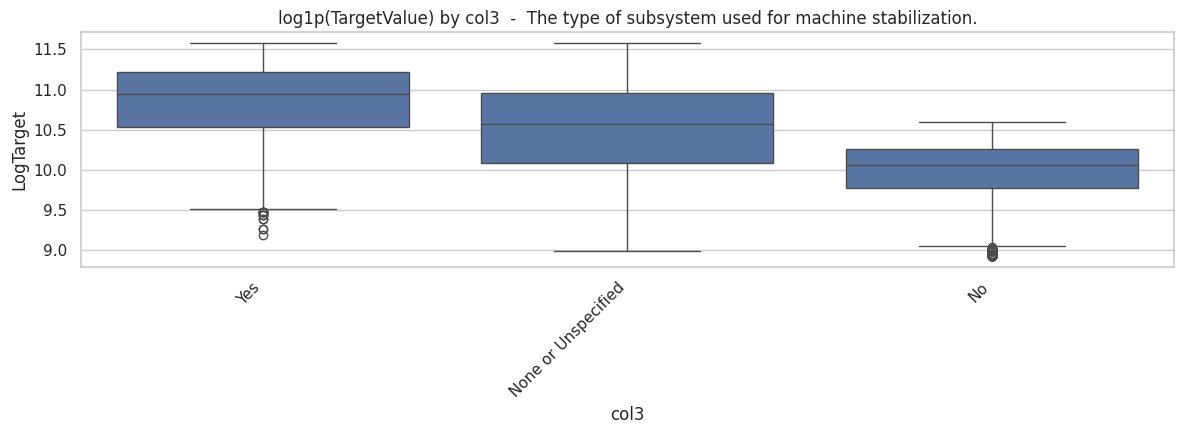

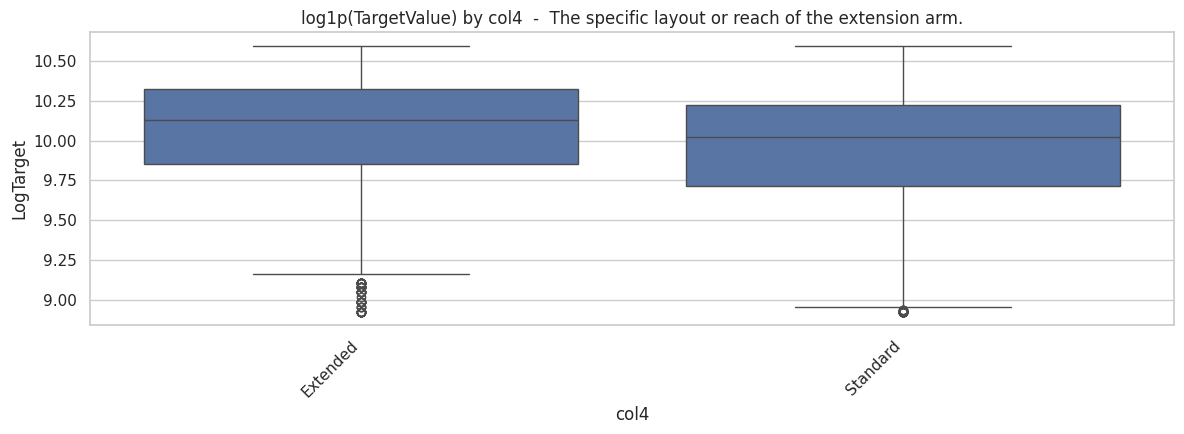

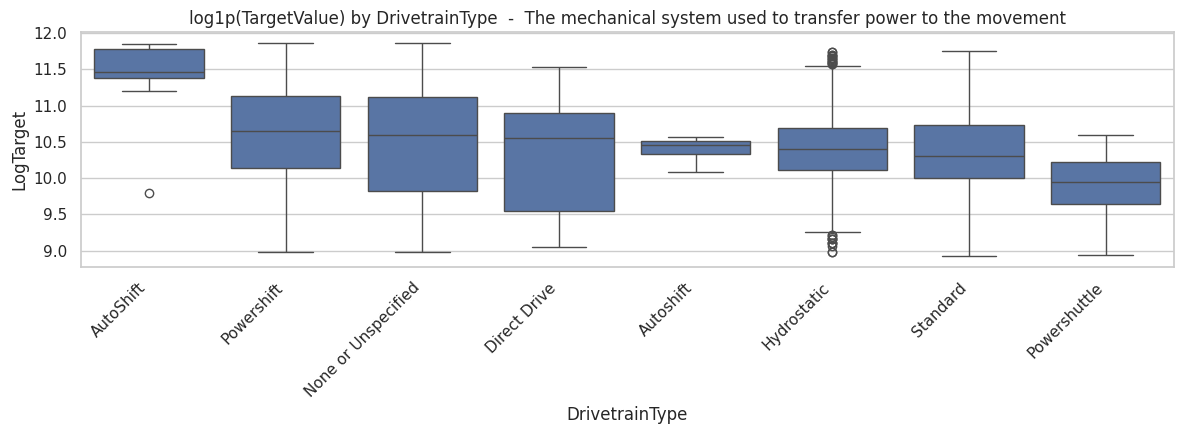

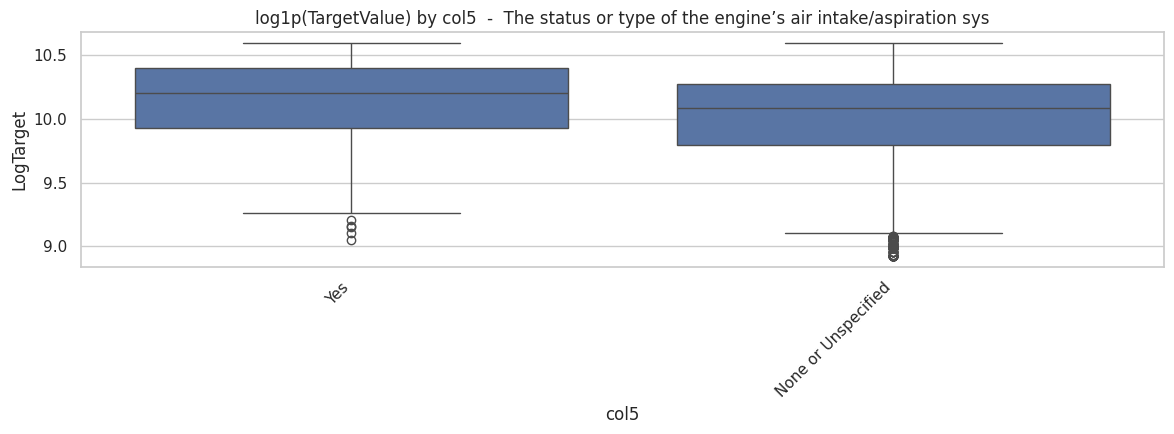

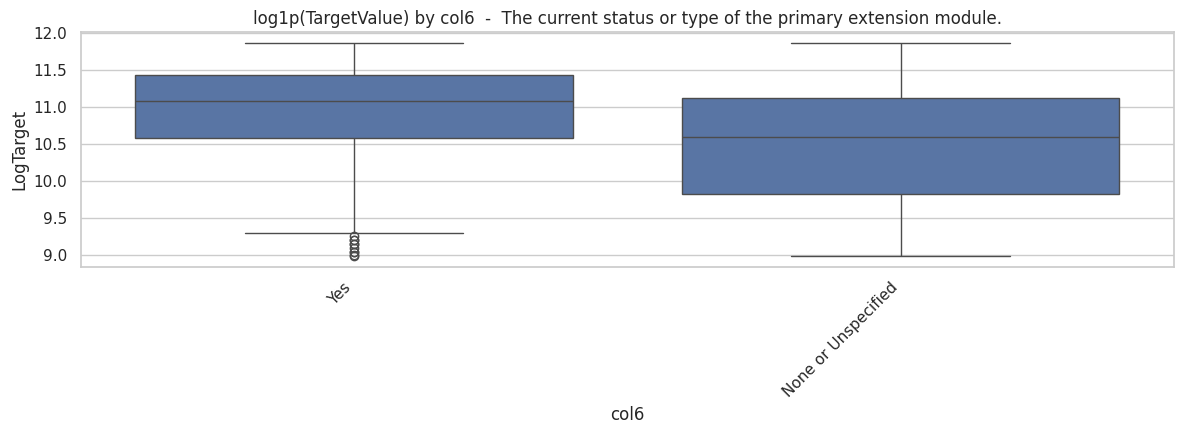

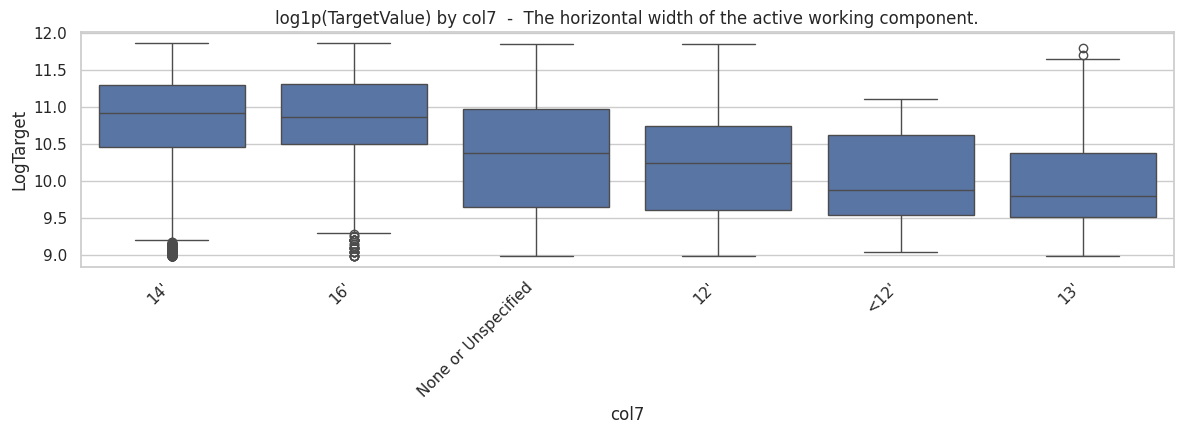

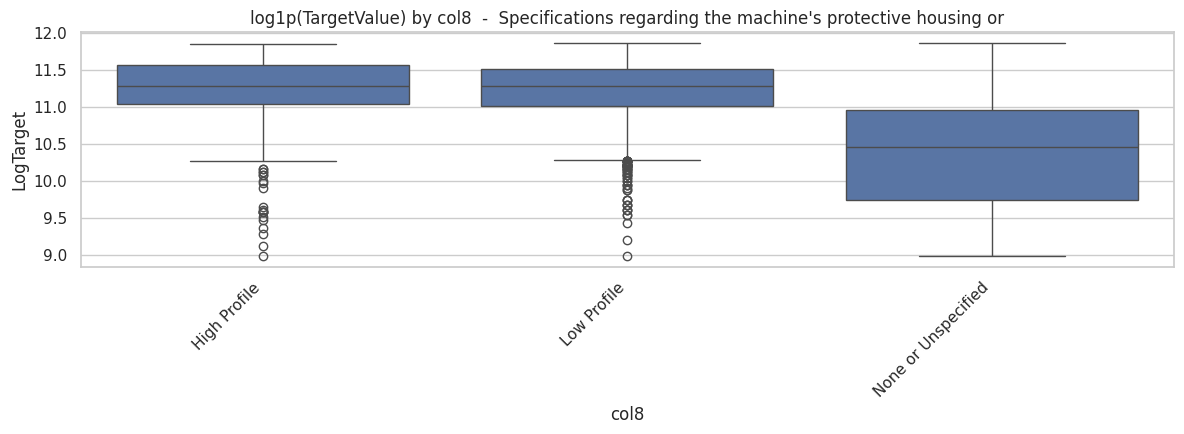

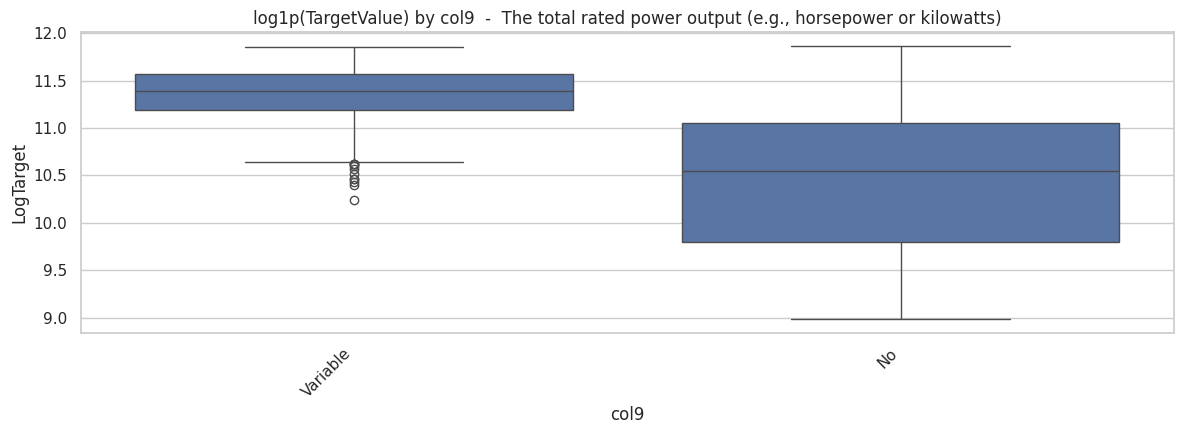

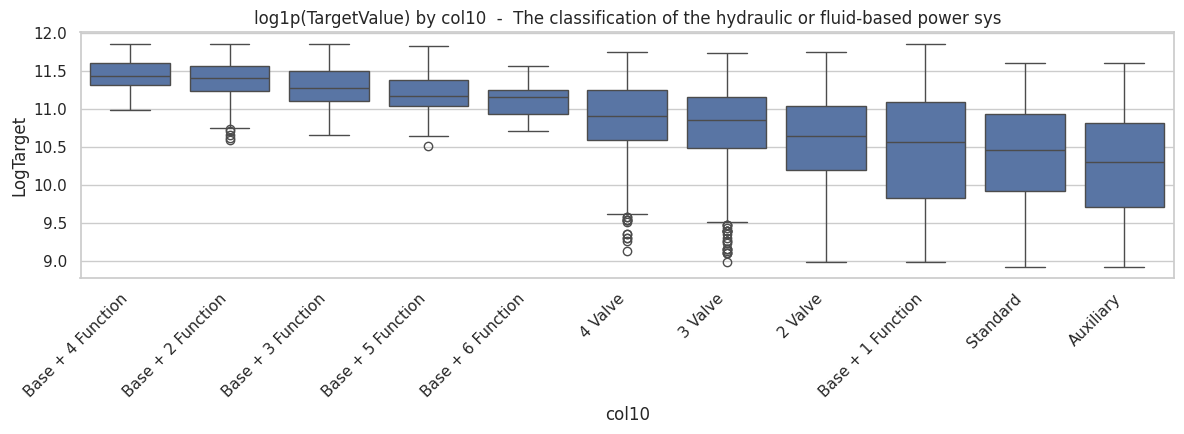

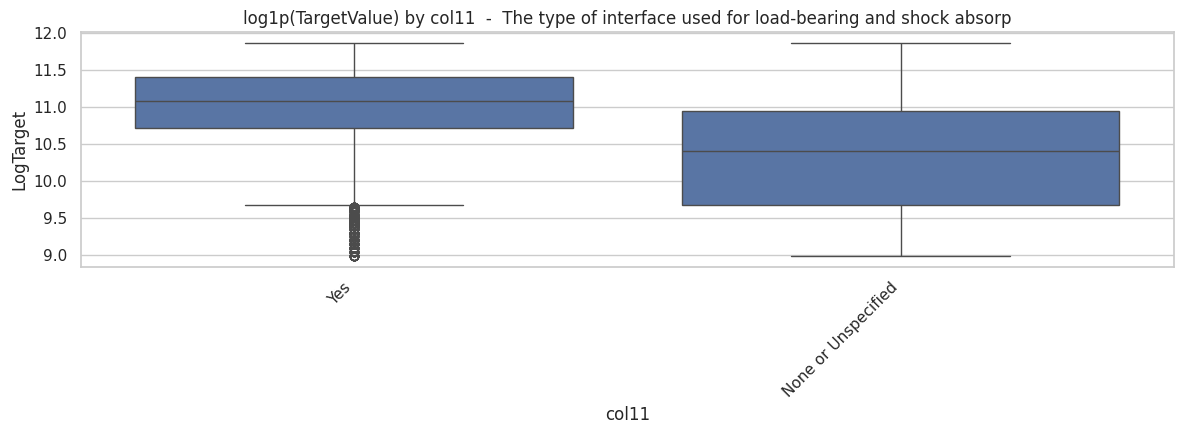

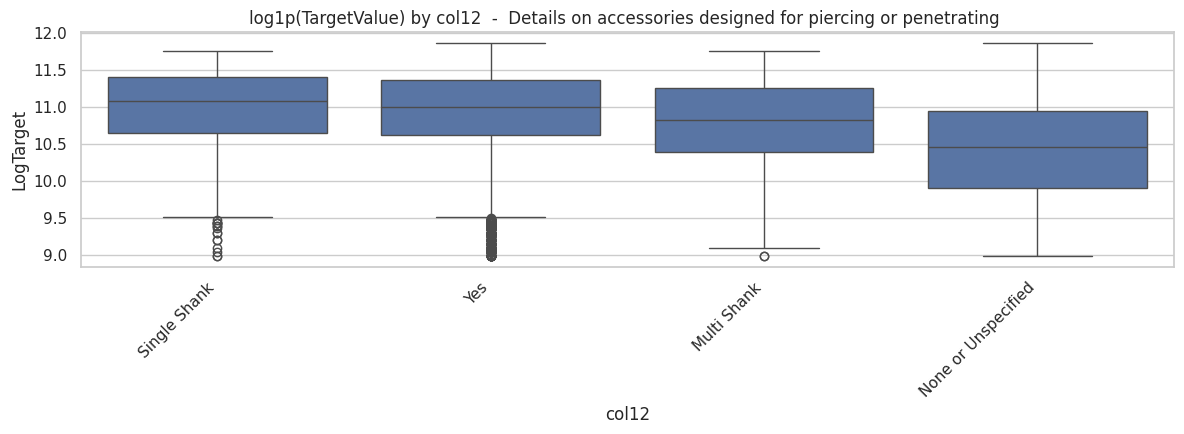

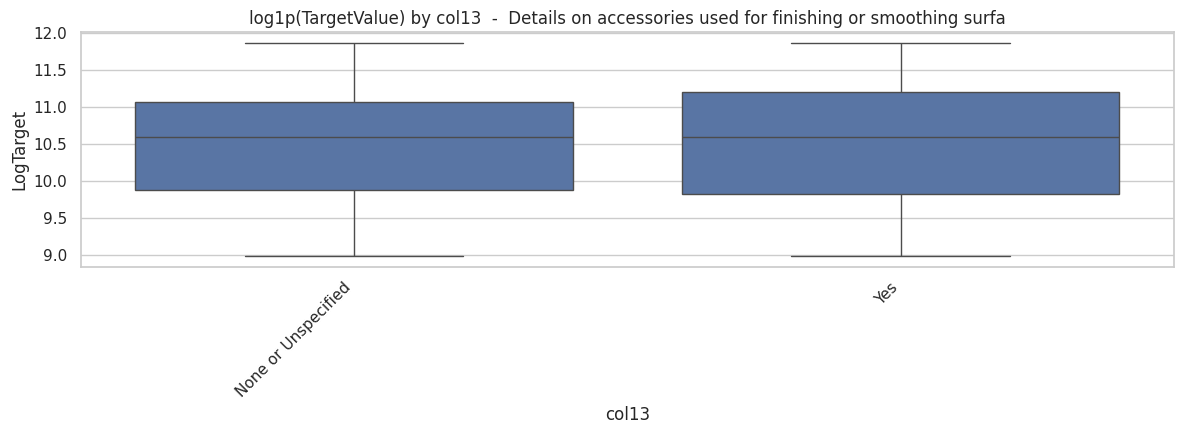

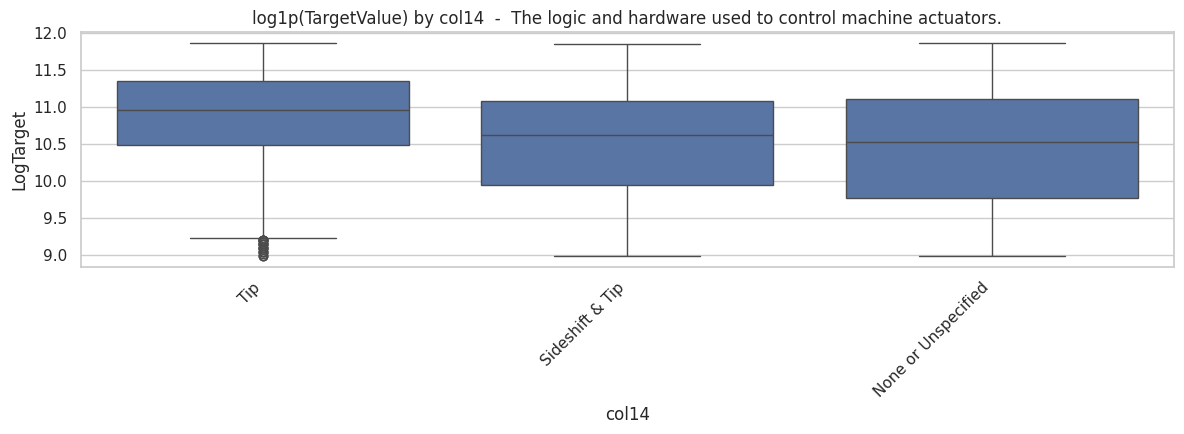

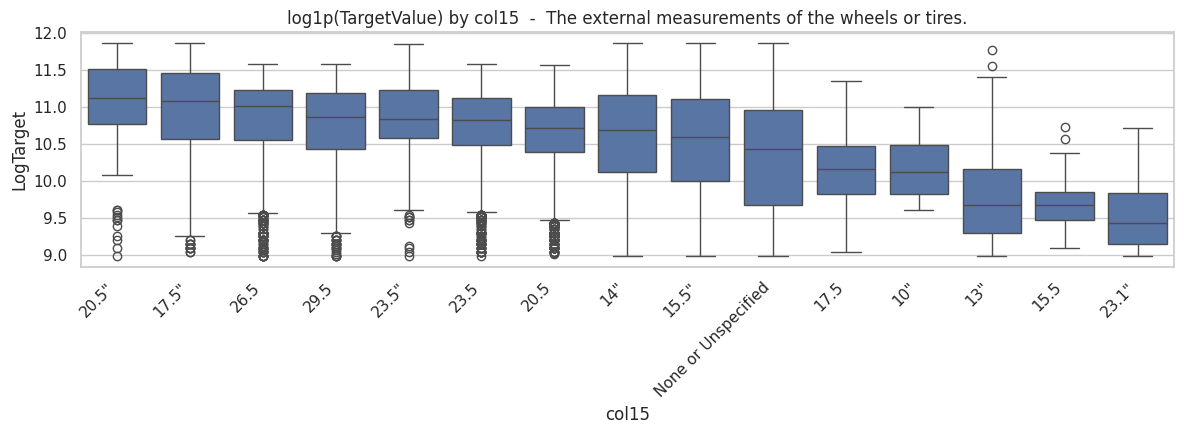

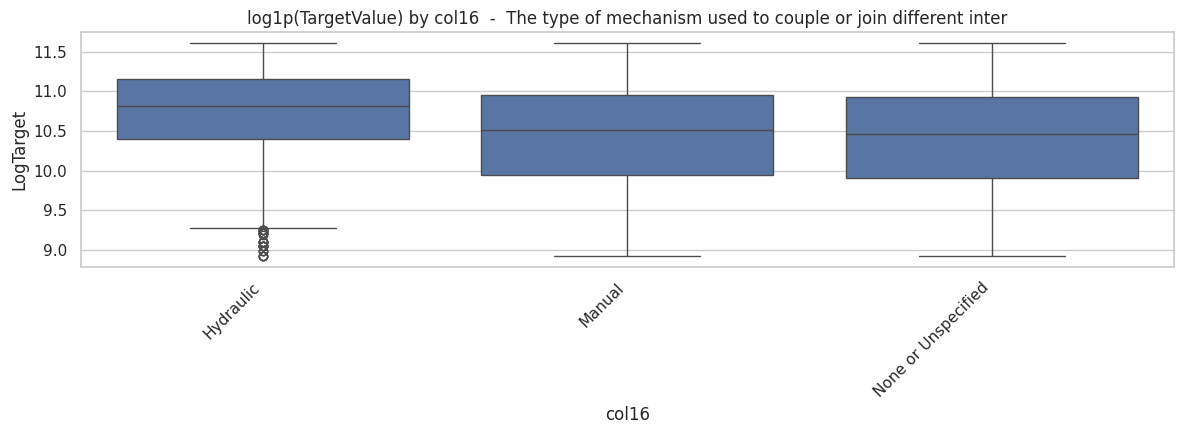

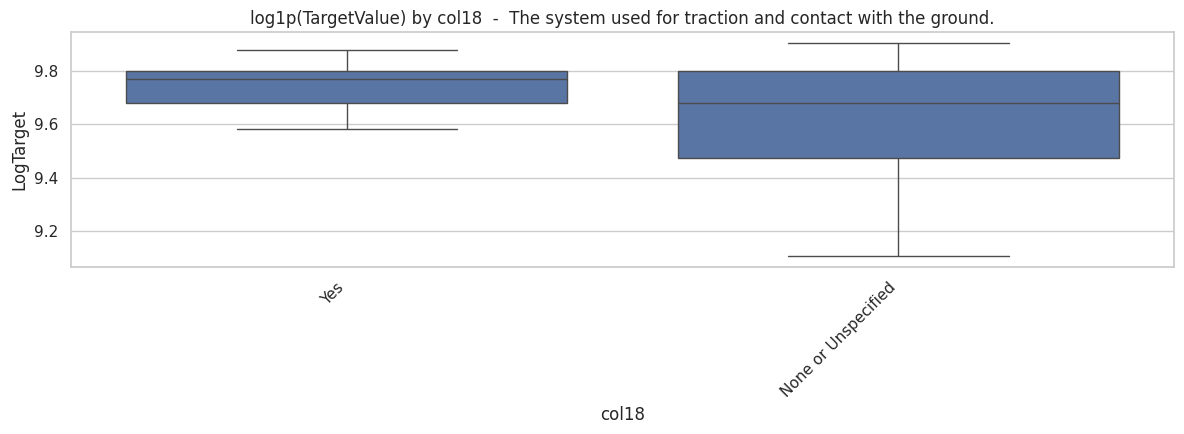

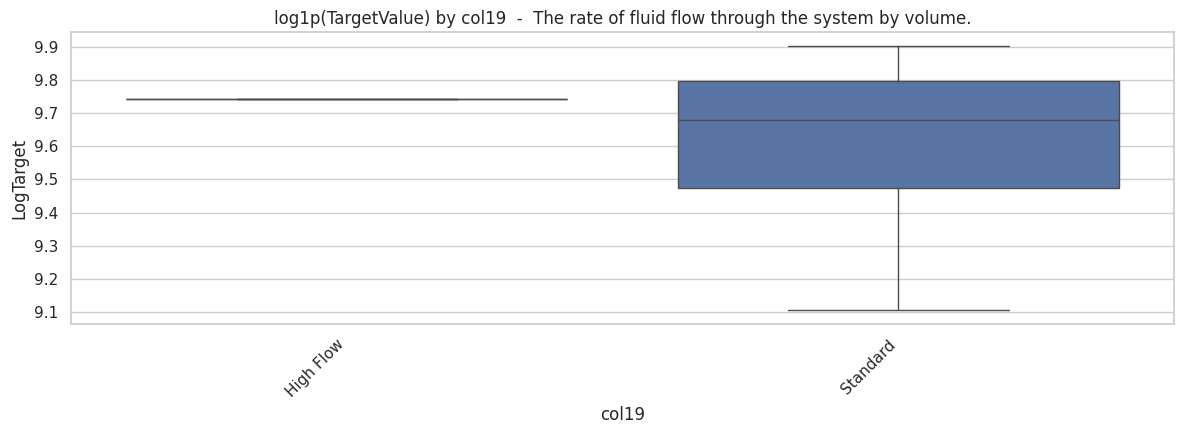

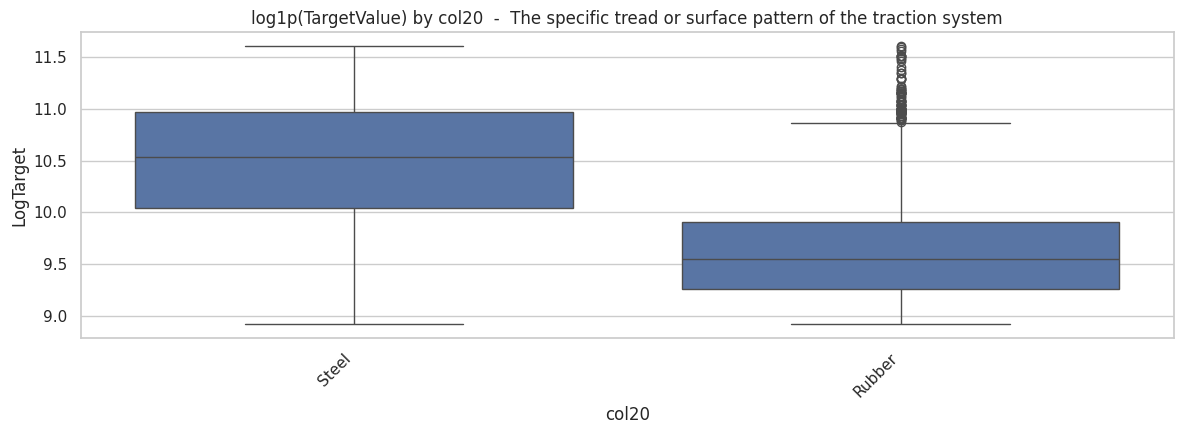

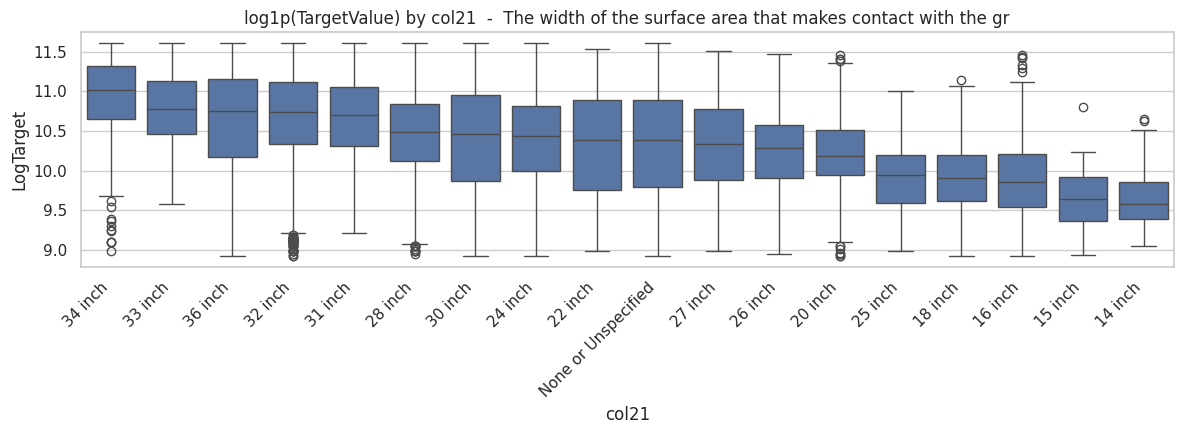

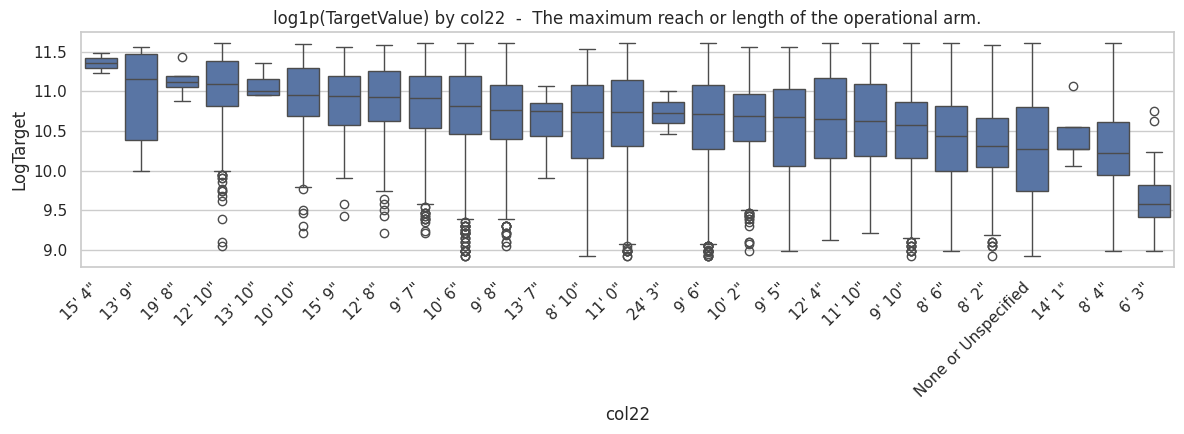

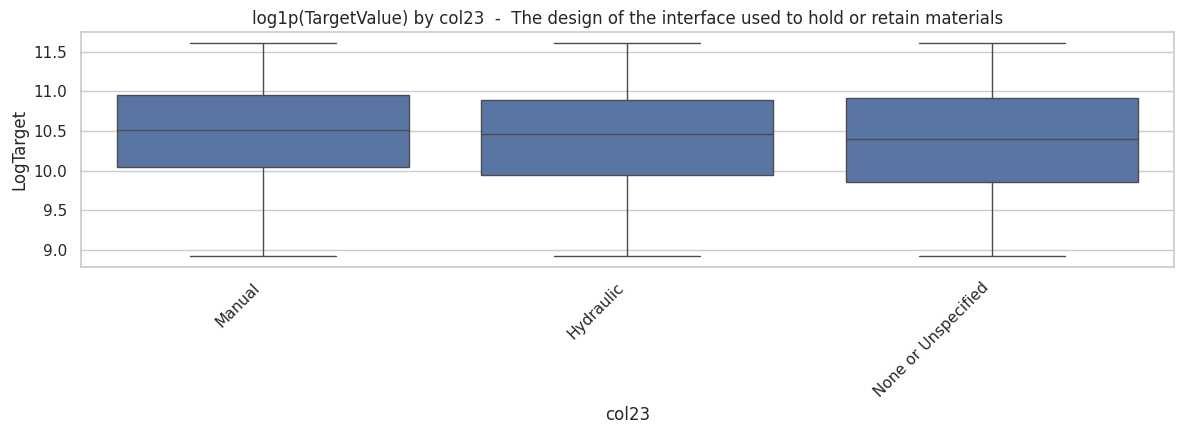

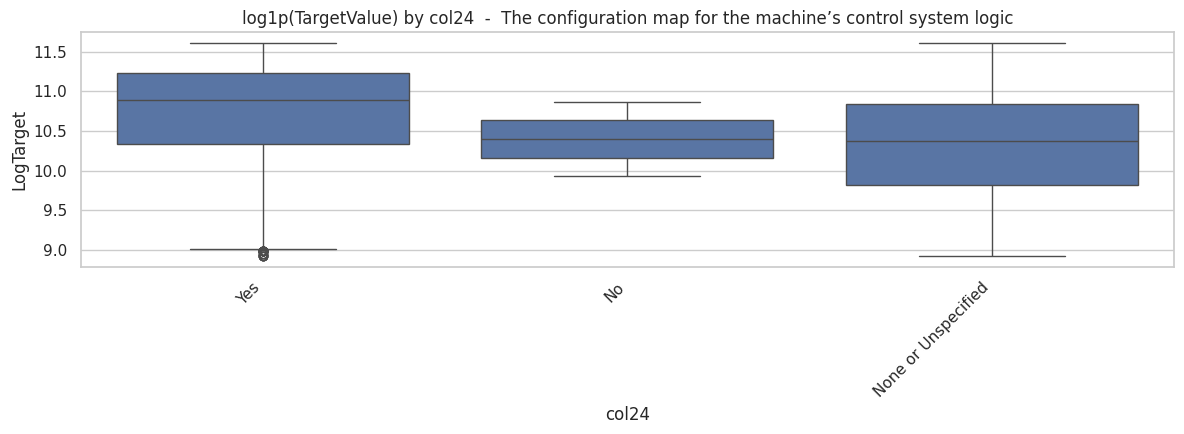

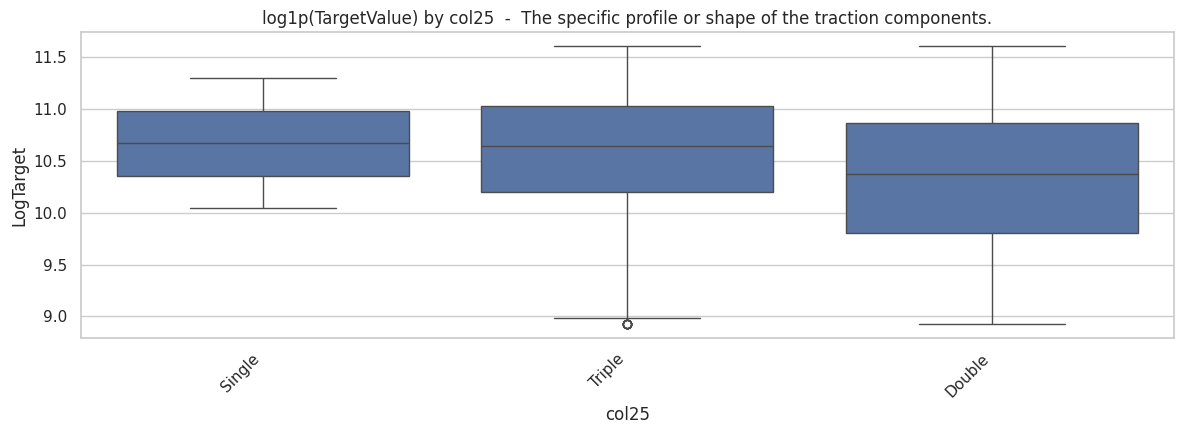

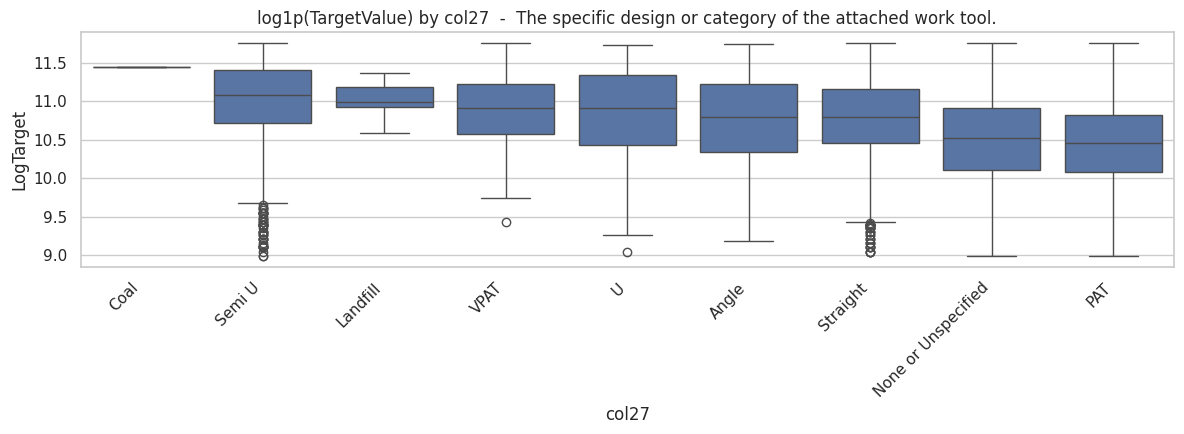

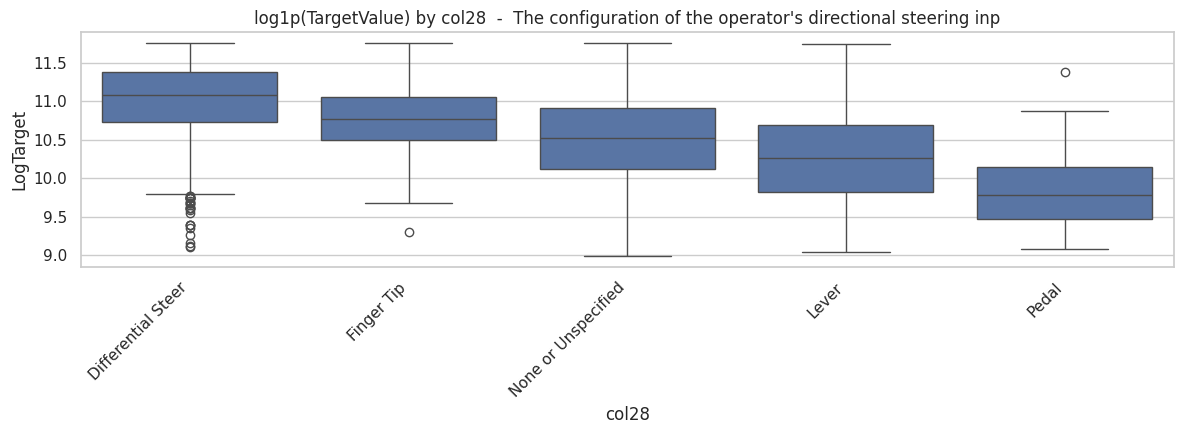

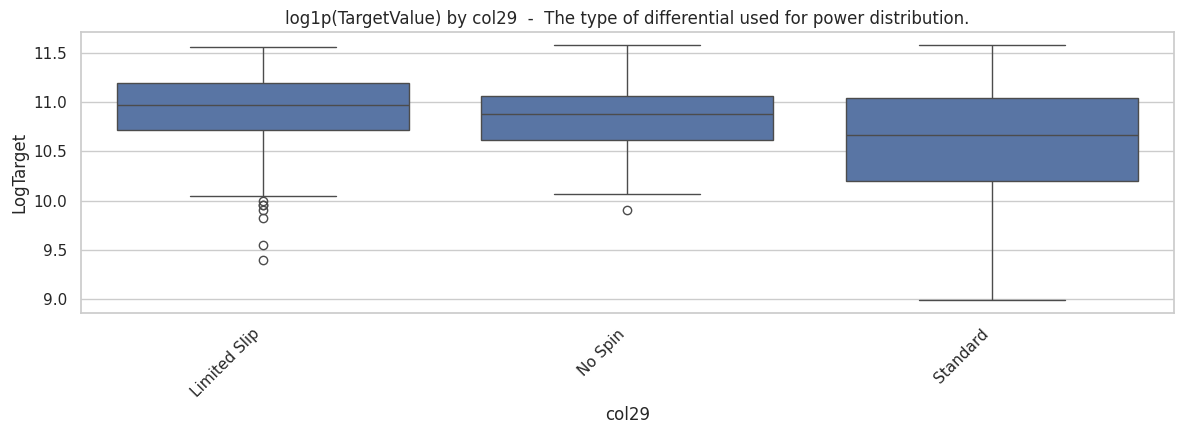

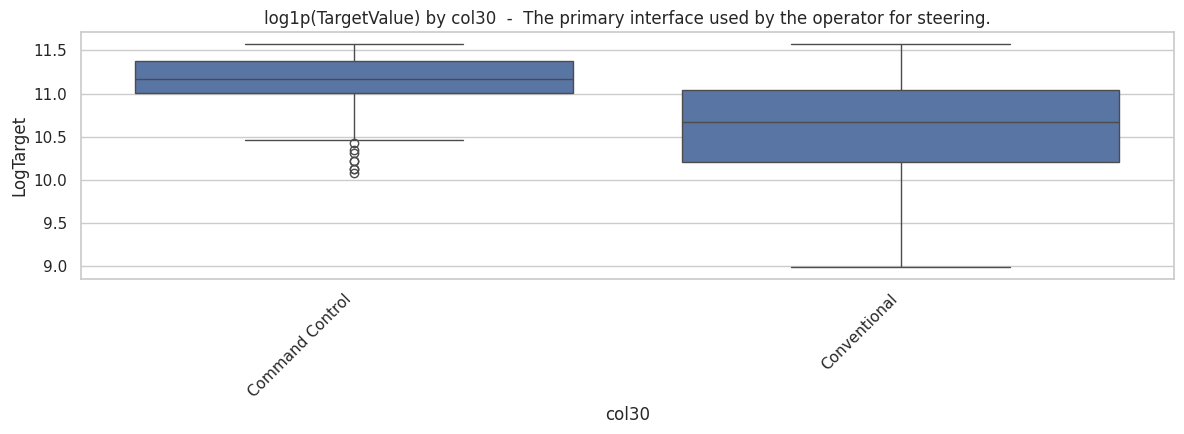

In [26]:
plot_df = train.assign(LogTarget=y_log_full)
box_cols = [c for c in categorical_cols if train[c].nunique() <= 30]

for col in box_cols:
    order = plot_df.groupby(col)["LogTarget"].median().sort_values(ascending=False).index
    plt.figure(figsize=(12, 4.5))
    sns.boxplot(data=plot_df, x=col, y="LogTarget", order=order)
    plt.title(f"log1p(TargetValue) by {col}  -  {describe_col(col)[:60]}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

### Correlation Heatmap

Spearman (rank) correlation of the numeric features with the log target, lower triangle only.

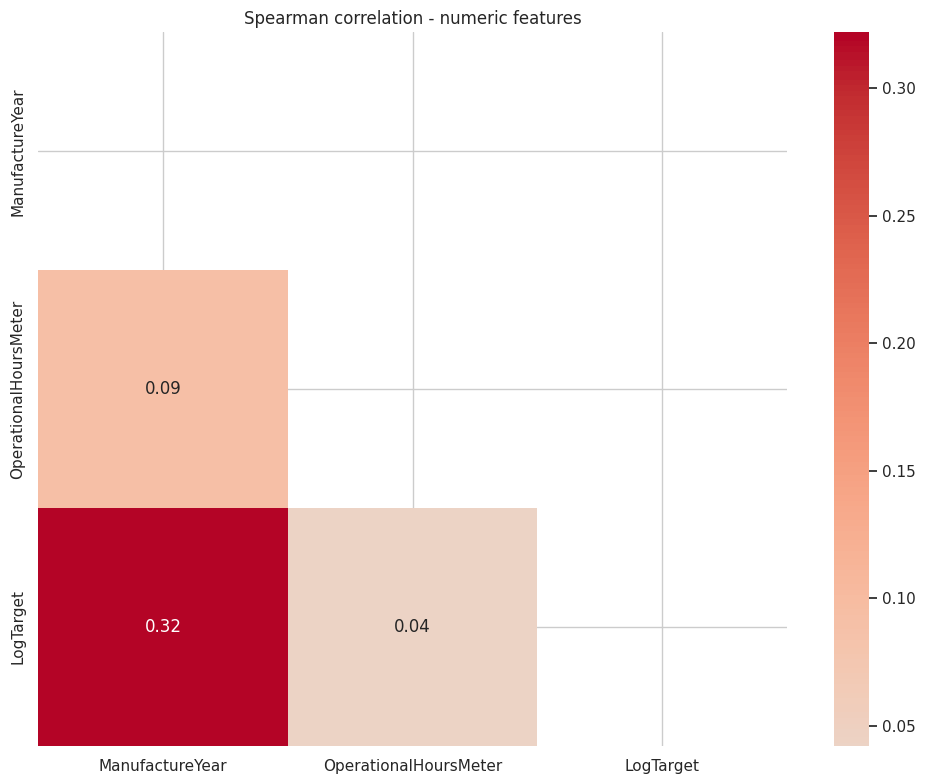

In [27]:
corr = plot_df[feature_num_cols + ["LogTarget"]].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation - numeric features")
plt.tight_layout(); plt.show()

# Outlier Detection
IQR rule (`Q1 - 1.5·IQR`, `Q3 + 1.5·IQR`) on the **numeric measurement columns only**: identifiers carry no physical meaning
and the target is never clipped.

In [28]:
iqr_bounds, rows = {}, []
for col in feature_num_cols:
    q1, q3 = train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_bounds[col] = (lo, hi)
    n_out = int(((train[col] < lo) | (train[col] > hi)).sum())
    rows.append({"feature": col, "lower": lo, "upper": hi, "n_outliers": n_out, "pct_outliers": 100 * n_out / len(train)})

outlier_df = pd.DataFrame(rows).set_index("feature").sort_values("n_outliers", ascending=False)
display(outlier_df.round(2))
print("Total flagged values (measurement columns only):", outlier_df["n_outliers"].sum())

,lower,upper,n_outliers,pct_outliers
feature,,,,
ManufactureYear,1969.0,2025.0,16026,11.55
OperationalHoursMeter,-7501.5,12502.5,4503,3.25


Total flagged values (measurement columns only): 20529


**Decision:** only `OperationalHoursMeter` is clipped. It is a continuous, heavy-tailed measurement where extreme meter readings are
plausible errors. The other columns are discrete codes / years / scale factors; for those, IQR is not meaningful (IQR can be 0, which
flags every non-modal value) and tree models are insensitive to extremes anyway. Bounds are learned on **train** and applied to
**test** (no information flows from test to train).

In [29]:
clip_cols = ["OperationalHoursMeter"]

for col in clip_cols:
    lo, hi = iqr_bounds[col]
    lo = max(lo, 0)                                   # a meter reading cannot be negative
    n_tr = int(((train[col] < lo) | (train[col] > hi)).sum())
    n_te = int(((test[col] < lo) | (test[col] > hi)).sum())

    train[col] = train[col].clip(lo, hi)              # NaN stay NaN
    test[col] = test[col].clip(lo, hi)
    print(f"{col}: clipped {n_tr} train values and {n_te} test values to [{lo:.1f}, {hi:.1f}]")

OperationalHoursMeter: clipped 4503 train values and 501 test values to [0.0, 12502.5]


# Data Cleaning

Problems are now **detected by code on every categorical column** (instead of eyeballing a few rows):
1. Excel error strings such as `#NAME?`
2. other suspicious placeholder strings (reported, not blindly removed - e.g. "Unspecified" can be a genuine category)
3. the same category spelled with different case / spaces (e.g. `AutoShift` vs `Autoshift`)

In [30]:
EXCEL_ERRORS = {"#NAME?", "#N/A", "#VALUE!", "#REF!", "#DIV/0!"}
SUSPICIOUS = {"", "?", "-", "--", "n/a", "na", "nan", "none", "null", "unknown", "unspecified"}

excel_hits = {c: int(train[c].isin(EXCEL_ERRORS).sum()) for c in categorical_cols}
excel_hits = {c: n for c, n in excel_hits.items() if n}
print("Excel-error strings found (column: count):", excel_hits)

suspicious_hits = {}
for c in categorical_cols:
    vals = train[c].dropna().astype(str).str.strip().str.lower()
    hit = vals[vals.isin(SUSPICIOUS)].value_counts()
    if len(hit):
        suspicious_hits[c] = hit.to_dict()
print("\nOther suspicious placeholder values (review manually):")
for c, h in suspicious_hits.items():
    print(f"  {c}: {h}")

norm = lambda s: s.str.strip().str.lower()
case_dups = {c: (train[c].nunique(), norm(train[c]).nunique())
             for c in categorical_cols if train[c].nunique() != norm(train[c]).nunique()}
print("\nColumns whose categories differ only by case/whitespace (raw nunique, normalised nunique):", case_dups)

Excel-error strings found (column: count): {'Spec_SubClass': 7, 'Spec_ReleaseSeries': 350}

Other suspicious placeholder values (review manually):
  RegionCode: {'unspecified': 586}

Columns whose categories differ only by case/whitespace (raw nunique, normalised nunique): {'Spec_SubClass': (147, 144), 'Spec_VariantModifier': (132, 128), 'DrivetrainType': (8, 7)}


In [31]:
# 1) Excel errors -> real missing values (train AND test, every categorical column)
for df in (train, test):
    df[categorical_cols] = df[categorical_cols].replace(list(EXCEL_ERRORS), np.nan)

# 2) normalise case / whitespace only in the columns that actually have such duplicates
for c in case_dups:
    for df in (train, test):
        df[c] = norm(df[c])
    print(f"{c}: {case_dups[c][0]} -> {train[c].nunique()} categories")

Spec_SubClass: 147 -> 143 categories
Spec_VariantModifier: 132 -> 128 categories
DrivetrainType: 8 -> 7 categories


In [32]:
# 3) ManufactureYear placeholder (years < 1900 such as 1001 / 1000 mean "unknown")
for df in (train, test):
    placeholder = df["ManufactureYear"] < 1900
    df["ManufactureYear_was_placeholder"] = placeholder.astype(int)
    df.loc[placeholder, "ManufactureYear"] = np.nan

print("Placeholder years  train:", train["ManufactureYear_was_placeholder"].sum(),
      f"({train['ManufactureYear_was_placeholder'].mean():.2%})   test:", test["ManufactureYear_was_placeholder"].sum())
print(train["ManufactureYear"].describe())

Placeholder years  train: 14719 (10.61%)   test: 1580
count    123982.000000
mean       1997.376708
std           8.895847
min        1920.000000
25%        1994.000000
50%        1999.000000
75%        2005.000000
max        2015.000000
Name: ManufactureYear, dtype: float64


In [33]:
# 4) AssetID: see the identifier investigation above. It is (near) unique per row, so it is dropped.
train = train.drop(columns=["AssetID"], errors="ignore")
test = test.drop(columns=["AssetID"], errors="ignore")

# 5) ProductConfigID looks numeric but is a product CODE: 2000 is not "more" than 1000. Treat as categorical.
for df in (train, test):
    df["ProductConfigID"] = df["ProductConfigID"].astype(str).where(df["ProductConfigID"].notna())
print("ProductConfigID unique codes:", train["ProductConfigID"].nunique())

ProductConfigID unique codes: 3594


In [34]:
# re-check missing values after cleaning
missing_after = train.isnull().sum().sort_values(ascending=False)
missing_after_df = pd.DataFrame({"missing_count": missing_after,
                                 "missing_pct": (missing_after / len(train) * 100).round(2)})
missing_after_df = missing_after_df[missing_after_df["missing_count"] > 0]
print("Remaining missing values after cleaning:")
display(missing_after_df)

Remaining missing values after cleaning:


,missing_count,missing_pct
col18,138635,99.95
col19,138635,99.95
col4,128320,92.52
col5,128320,92.52
col28,123742,89.21
col27,123742,89.21
col30,119829,86.39
col29,119829,86.39
col14,115296,83.13
col9,115296,83.13


# Feature Engineering

In [35]:
train_fe = train.copy()
test_fe = test.copy()

### 1. Redundant / useless columns
Dropping is only done **after the data proves it is safe**:
* `InventoryGroupDescription` vs `InventoryGroupCategory` - verify they are a strict one-to-one mapping *and* contain no nulls.
* Columns with > 95 % missing values carry no usable signal.

In [36]:
pair = train_fe[["InventoryGroupDescription", "InventoryGroupCategory"]]
print("nulls per column:\n", pair.isnull().sum(), "\n")

max_cat_per_desc = pair.groupby("InventoryGroupDescription")["InventoryGroupCategory"].nunique().max()
max_desc_per_cat = pair.groupby("InventoryGroupCategory")["InventoryGroupDescription"].nunique().max()
print("max categories per description:", max_cat_per_desc)
print("max descriptions per category :", max_desc_per_cat)

one_to_one = (max_cat_per_desc == 1) and (max_desc_per_cat == 1)
print("Strict one-to-one mapping:", one_to_one)

if one_to_one:
    train_fe = train_fe.drop(columns=["InventoryGroupDescription"])
    test_fe = test_fe.drop(columns=["InventoryGroupDescription"])
    print("-> InventoryGroupDescription dropped (carries no extra information)")
else:
    print("-> mapping is NOT one-to-one, both columns are kept")

nulls per column:
 InventoryGroupDescription    0
InventoryGroupCategory       0
dtype: int64 

max categories per description: 1
max descriptions per category : 1
Strict one-to-one mapping: True
-> InventoryGroupDescription dropped (carries no extra information)


In [37]:
drop_high_missing = [c for c in missing_df.index[missing_df["missing_pct"] > 95] if c in train_fe.columns]
for c in drop_high_missing:
    print(f"{c}: {missing_df.loc[c, 'missing_pct']}% missing  |  {describe_col(c)}")

train_fe = train_fe.drop(columns=drop_high_missing)
test_fe = test_fe.drop(columns=drop_high_missing)

col19: 99.95% missing  |  The rate of fluid flow through the system by volume.
col18: 99.95% missing  |  The system used for traction and contact with the ground.


### 2. New features (one function, applied identically to train and test)
| Feature | Meaning |
|---|---|
| `SaleYear / Month / Quarter / DayOfWeek` | calendar information from `TransactionDate` |
| `EquipmentAge` | `SaleYear - ManufactureYear` (NaN when the year is unknown or the age would be negative) |
| `LogHours` | `log1p(OperationalHoursMeter)` - tames the right skew |
| `HoursPerYear` | usage intensity: hours relative to age |
| `AgeXHours` | interaction of age and total hours |
| `NumSpecsPresent` | how many spec columns are filled (better documented machines) |

**Note on NaN:** if `ManufactureYear` is unknown then `EquipmentAge`, `HoursPerYear` and `AgeXHours` are NaN as well (NaN − number = NaN).
That is the honest answer. Median-imputing the year *and* the age independently would produce an age that contradicts the year (the issue
raised in the review), so tree models receive these NaNs directly and the `*_was_missing` / `_was_placeholder` flags keep the information.

In [38]:
spec_cols = [c for c in train_fe.columns if re.fullmatch(r"col\d+", c.lower())]
print(f"{len(spec_cols)} anonymous spec columns used for NumSpecsPresent")


def add_features(df, spec_cols):
    """Create all engineered features. Same function for train and test -> no copy/paste drift."""
    df = df.copy()
    df["SaleYear"] = df["TransactionDate"].dt.year
    df["SaleMonth"] = df["TransactionDate"].dt.month
    df["SaleQuarter"] = df["TransactionDate"].dt.quarter
    df["SaleDayOfWeek"] = df["TransactionDate"].dt.dayofweek

    df["EquipmentAge"] = df["SaleYear"] - df["ManufactureYear"]          # NaN if year unknown
    df.loc[df["EquipmentAge"] < 0, "EquipmentAge"] = np.nan             # sold before it was built -> invalid

    df["LogHours"] = np.log1p(df["OperationalHoursMeter"])
    df["HoursPerYear"] = df["OperationalHoursMeter"] / (df["EquipmentAge"] + 1)
    df["AgeXHours"] = df["EquipmentAge"] * df["OperationalHoursMeter"]
    df["NumSpecsPresent"] = df[spec_cols].notnull().sum(axis=1)
    return df


base_columns = set(train_fe.columns)
train_fe = add_features(train_fe, spec_cols)
test_fe = add_features(test_fe, spec_cols)

new_cols = [c for c in train_fe.columns if c not in base_columns]
print(f"total new columns added: {len(new_cols)}")
print(new_cols)
print("train_fe:", train_fe.shape, "| test_fe:", test_fe.shape)

25 anonymous spec columns used for NumSpecsPresent
total new columns added: 9
['SaleYear', 'SaleMonth', 'SaleQuarter', 'SaleDayOfWeek', 'EquipmentAge', 'LogHours', 'HoursPerYear', 'AgeXHours', 'NumSpecsPresent']
train_fe: (138701, 56) | test_fe: (15000, 55)


In [39]:
# look at the new features right after creating them (sanity check, as recommended in the review)
display(train_fe[["TransactionDate", "ManufactureYear", "OperationalHoursMeter"] + new_cols].head(8))
display(train_fe[new_cols].describe().T)

print("NaN in EquipmentAge  train:", train_fe["EquipmentAge"].isnull().sum(), "| test:", test_fe["EquipmentAge"].isnull().sum())
print("Negative ages turned to NaN or invalid:", (train_fe["SaleYear"] < train_fe["ManufactureYear"]).sum())

,TransactionDate,ManufactureYear,OperationalHoursMeter,SaleYear,SaleMonth,SaleQuarter,SaleDayOfWeek,EquipmentAge,LogHours,HoursPerYear,AgeXHours,NumSpecsPresent
0,2005-03-26,1997.0,4640.0,2005,3,1,5,8.0,8.442685,515.555556,37120.0,6
1,2009-12-18,2005.0,508.0,2009,12,4,4,4.0,6.232448,101.600000,2032.0,4
2,2005-08-26,1994.0,11540.0,2005,8,3,4,11.0,9.353661,961.666667,126940.0,8
3,2006-11-17,2002.0,4883.0,2006,11,4,4,4.0,8.493720,976.600000,19532.0,4
4,2010-08-27,2009.0,302.0,2010,8,3,4,1.0,5.713733,151.000000,302.0,8
5,2008-08-09,NaN,12502.5,2008,8,3,5,NaN,9.433764,NaN,NaN,6
6,2009-08-21,2005.0,1414.0,2009,8,3,4,4.0,7.254885,282.800000,5656.0,4
7,2006-10-20,1999.0,0.0,2006,10,4,4,7.0,0.000000,0.000000,0.0,8


,count,mean,std,min,25%,50%,75%,max
SaleYear,138701.0,2007.489932,4.792396,1990.0,2005.0,2009.000000,2011.000000,2013.000000
SaleMonth,138701.0,6.257597,3.447017,1.0,3.0,6.000000,9.000000,12.000000
SaleQuarter,138701.0,2.336256,1.142892,1.0,1.0,2.000000,3.000000,4.000000
SaleDayOfWeek,138701.0,3.550313,1.418962,0.0,3.0,4.000000,4.000000,6.000000
EquipmentAge,123975.0,10.038661,7.418233,0.0,5.0,8.000000,13.000000,92.000000
LogHours,82058.0,5.010258,4.047319,0.0,0.0,7.390799,8.517593,9.433764
HoursPerYear,72849.0,361.384000,408.504850,0.0,0.0,271.000000,595.428571,6251.250000
AgeXHours,72849.0,31874.845296,54736.520282,0.0,0.0,7600.000000,37044.000000,562612.500000
NumSpecsPresent,138701.0,7.500429,2.180320,2.0,6.0,8.000000,8.000000,11.000000


NaN in EquipmentAge  train: 14726 | test: 1582
Negative ages turned to NaN or invalid: 7


### 3. Do the new features actually relate to price?
Each engineered feature is checked against the target (previously never inspected).

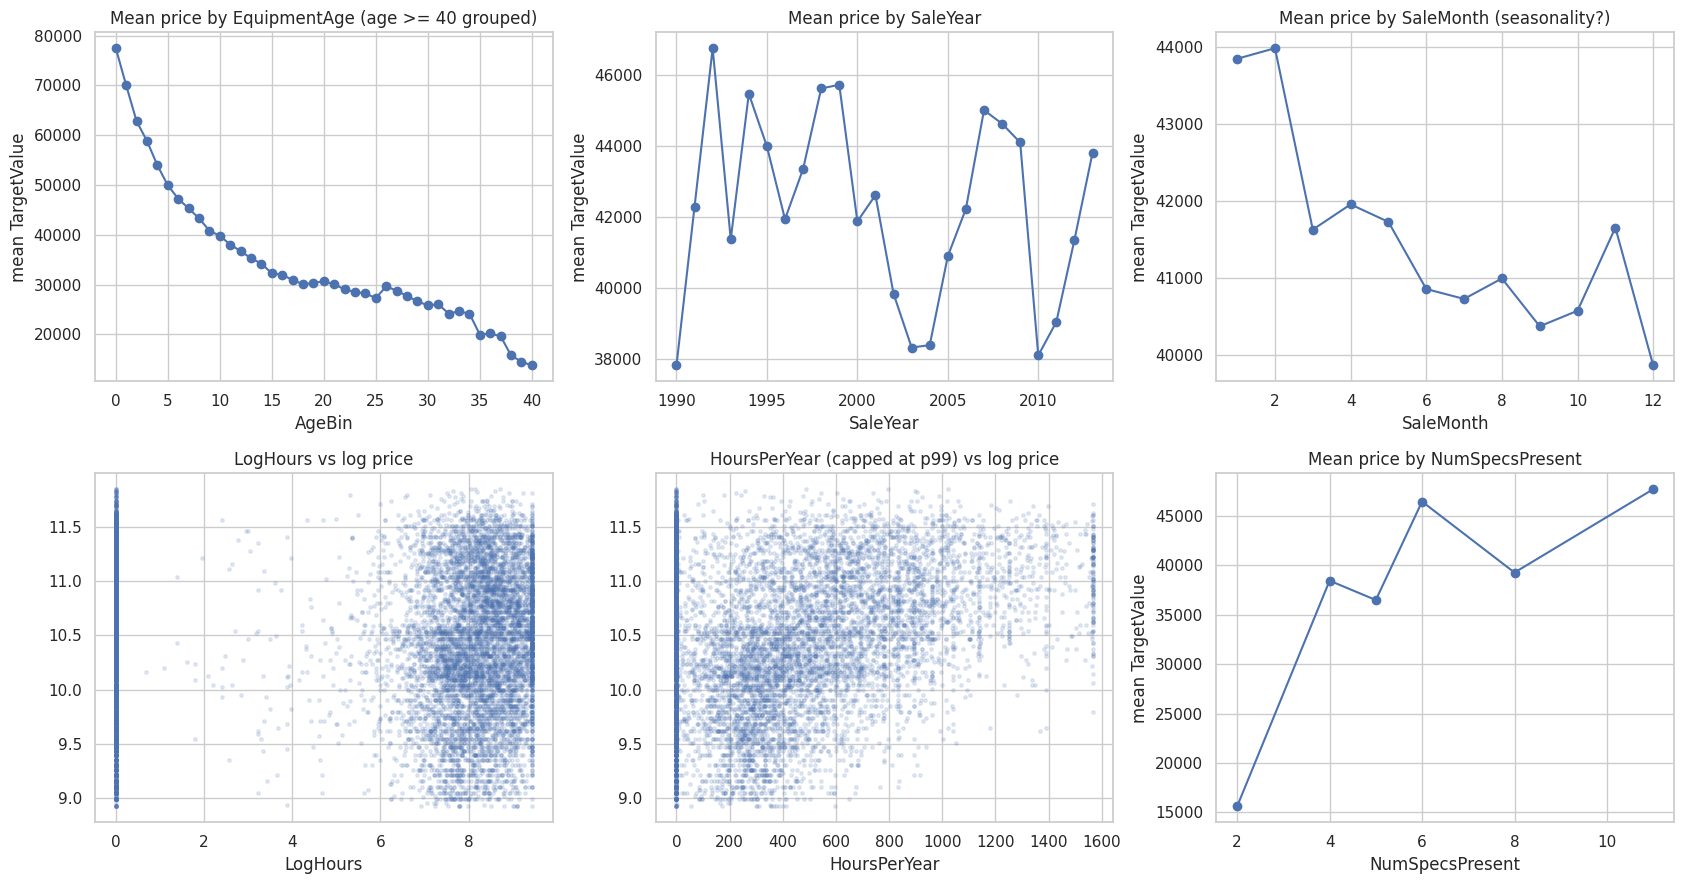

,pearson,spearman
EquipmentAge,-0.373,-0.384
HoursPerYear,0.219,0.151
AgeXHours,-0.073,-0.066
LogHours,0.016,0.042
SaleMonth,-0.033,-0.036
SaleYear,-0.025,-0.035
SaleQuarter,-0.030,-0.032
SaleDayOfWeek,-0.018,-0.024
NumSpecsPresent,0.023,0.022


In [40]:
fe_plot = train_fe.assign(LogTarget=np.log1p(train_fe["TargetValue"]))

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

age_bins = fe_plot.dropna(subset=["EquipmentAge"]).copy()
age_bins["AgeBin"] = age_bins["EquipmentAge"].clip(upper=40)
age_bins.groupby("AgeBin")["TargetValue"].mean().plot(ax=axes[0, 0], marker="o")
axes[0, 0].set_title("Mean price by EquipmentAge (age >= 40 grouped)"); axes[0, 0].set_ylabel("mean TargetValue")

fe_plot.groupby("SaleYear")["TargetValue"].mean().plot(ax=axes[0, 1], marker="o")
axes[0, 1].set_title("Mean price by SaleYear"); axes[0, 1].set_ylabel("mean TargetValue")

fe_plot.groupby("SaleMonth")["TargetValue"].mean().plot(ax=axes[0, 2], marker="o")
axes[0, 2].set_title("Mean price by SaleMonth (seasonality?)"); axes[0, 2].set_ylabel("mean TargetValue")

s = fe_plot.sample(min(20000, len(fe_plot)), random_state=SEED)
axes[1, 0].scatter(s["LogHours"], s["LogTarget"], alpha=0.15, s=6)
axes[1, 0].set_title("LogHours vs log price"); axes[1, 0].set_xlabel("LogHours")

hpy_cap = s["HoursPerYear"].quantile(0.99)
axes[1, 1].scatter(s["HoursPerYear"].clip(upper=hpy_cap), s["LogTarget"], alpha=0.15, s=6)
axes[1, 1].set_title("HoursPerYear (capped at p99) vs log price"); axes[1, 1].set_xlabel("HoursPerYear")

fe_plot.groupby("NumSpecsPresent")["TargetValue"].mean().plot(ax=axes[1, 2], marker="o")
axes[1, 2].set_title("Mean price by NumSpecsPresent"); axes[1, 2].set_ylabel("mean TargetValue")

plt.tight_layout(); plt.show()

fe_corr = pd.DataFrame({
    "pearson": fe_plot[new_cols].corrwith(fe_plot["LogTarget"]),
    "spearman": fe_plot[new_cols].corrwith(fe_plot["LogTarget"], method="spearman"),
}).round(3)
fe_corr = fe_corr.reindex(fe_corr["spearman"].abs().sort_values(ascending=False).index)
display(fe_corr)

*How to read this:* a clear trend in the mean-price curves (or a high |Spearman|) means the feature carries signal, a flat line means
it adds little. Features with weak signal here are the first candidates to remove if the model needs simplifying.

# Missing Value Indicator Flags
`<col>_was_missing` = 1 when the original value was empty. Missingness is often informative (e.g. older machines have fewer
recorded specs). The flag columns are decided on **train only** and re-used for test, and flags with an identical pattern
(perfectly duplicated information) are removed automatically, replacing the hard-coded exclusion list used before.

In [41]:
original_cols = [c for c in train_fe.columns if c in train.columns and c != "TargetValue"]   # not engineered, not target
cols_with_nan = [c for c in original_cols if train_fe[c].isnull().any()]

flags_train = train_fe[cols_with_nan].isnull().astype(int).add_suffix("_was_missing")
flags_train = flags_train.loc[:, ~flags_train.T.duplicated()]                 # drop duplicated flag columns
flag_source = {f: f[: -len("_was_missing")] for f in flags_train.columns}

flags_test = pd.DataFrame({f: test_fe[src].isnull().astype(int) for f, src in flag_source.items()})

train_fe = pd.concat([train_fe, flags_train], axis=1)
test_fe = pd.concat([test_fe, flags_test], axis=1)

print(f"{len(cols_with_nan)} columns with NaN -> {flags_train.shape[1]} unique missing-flags created")
print("train_fe:", train_fe.shape, "| test_fe:", test_fe.shape)

34 columns with NaN -> 21 unique missing-flags created
train_fe: (138701, 77) | test_fe: (15000, 76)


# Train / Validation Split
80 % train / 20 % validation. `random_state` only makes the split reproducible. First we check whether the test set lies in the same
time window as train (if test were *later* in time, a time-based split would be the more honest validation).

In [42]:
print("train period:", train_fe["TransactionDate"].min().date(), "->", train_fe["TransactionDate"].max().date())
print("test  period:", test_fe["TransactionDate"].min().date(), "->", test_fe["TransactionDate"].max().date())

X = train_fe.drop(columns=["TargetValue", "TransactionDate", "TransactionID"])
y = train_fe["TargetValue"]
X_test = test_fe.drop(columns=["TransactionDate", "TransactionID"])[X.columns]      # same columns, same order
assert list(X.columns) == list(X_test.columns)

train period: 1990-01-31 -> 2013-04-28
test  period: 1990-01-31 -> 2013-04-28


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [44]:
# TargetValue is right-skewed -> train on log1p(TargetValue)  (log1p instead of log because log(0) is undefined, log1p(0) = 0)
# Predictions are converted back with expm1 before submission.
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

X_train shape : (110960, 74)
X_val shape   : (27741, 74)
X_test shape  : (15000, 74)


# Preprocessing

In [45]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"{len(num_cols)} numerical columns, {len(cat_cols)} categorical columns")

33 numerical columns, 41 categorical columns


In [46]:
# split categorical features by cardinality (number of unique values)
high_card_threshold = 50          # > 50 unique values -> high-cardinality column

high_card_cols = [c for c in cat_cols if X_train[c].nunique() > high_card_threshold]
low_card_cols = [c for c in cat_cols if X_train[c].nunique() <= high_card_threshold]

print(f"high-cardinality columns ({len(high_card_cols)}): {high_card_cols}")
print(f"low-cardinality columns  ({len(low_card_cols)}): {low_card_cols}")

high-cardinality columns (8): ['ProductConfigID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification', 'RegionCode']
low-cardinality columns  (33): ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'AssetScaleFactor', 'InventoryGroupCategory', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


### Rare categories
In the **low-cardinality** columns every category that appears **fewer than 20 times** (a *frequency* threshold - the earlier
comment wrongly called it "cardinality") in the training set is merged into one `"other"` category. Reasons: such categories are too
rare to learn a reliable price effect from, and merging reduces noise and over-fitting. The rare list is learned on **train only** and then
applied unchanged to validation and test. The merged columns stay in `low_card_cols` and are encoded together with the others.

In [47]:
RARE_MIN_COUNT = 20

# learn the rare categories on TRAIN only
rare_map = {}
for col in low_card_cols:
    counts = X_train[col].value_counts()                       # NaN is not counted -> stays NaN, imputed later
    rare = counts[counts < RARE_MIN_COUNT].index.tolist()
    if rare:
        rare_map[col] = rare


def merge_rare(df):
    """Apply the train-learned rare-category mapping to any dataframe."""
    df = df.copy()
    for col, rare in rare_map.items():
        df[col] = df[col].where(~df[col].isin(rare), "other")
    return df


rows_affected = sum(X_train[c].isin(r).sum() for c, r in rare_map.items())
print(f"columns with rare categories      : {len(rare_map)} of {len(low_card_cols)} low-cardinality columns")
print(f"total categories merged -> 'other': {sum(len(r) for r in rare_map.values())}")
print(f"cells re-labelled in X_train      : {rows_affected}")
print({c: len(r) for c, r in rare_map.items()})

X_train, X_val, X_test = merge_rare(X_train), merge_rare(X_val), merge_rare(X_test)

columns with rare categories      : 6 of 33 low-cardinality columns
total categories merged -> 'other': 15
cells re-labelled in X_train      : 96
{'DrivetrainType': 1, 'col15': 2, 'col21': 2, 'col22': 7, 'col24': 1, 'col27': 2}


### Encoding strategy
| Column type | Encoder | Why |
|---|---|---|
| High cardinality | **Target encoding** (`cv=5`, smoothed) | replaces a category by its (smoothed) mean log price; the 5-fold cross-fitting stops the encoder from seeing a row's own target (leakage) |
| Low cardinality - tree models | **Ordinal encoding** | trees split on thresholds, so an arbitrary integer code works and avoids hundreds of one-hot columns; unseen categories get `-1` |
| Low cardinality - Ridge | **One-hot encoding** | a linear model would read ordinal codes as a meaningful order (0 < 1 < 2), which is wrong for nominal categories |
| Numeric - Ridge / Gradient Boosting | median imputation | median is robust to outliers (mean is not); the models cannot handle NaN |
| Numeric - HistGB / LightGBM / XGBoost | **left as is** | they learn which side of a split NaN should go; avoids inventing a fake `ManufactureYear` / `EquipmentAge` |

In [48]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler


def high_card_pipe():
    return Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                     ("encode", TargetEncoder(target_type="continuous", cv=5, smooth="auto", random_state=SEED))])

def low_card_ordinal_pipe():
    return Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                     ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])

# (1) imputing preprocessor: for Gradient Boosting (cannot handle NaN)
preprocessor = ColumnTransformer([
    ("numeric_impute", SimpleImputer(strategy="median"), num_cols),
    ("high_card_cat_cols", high_card_pipe(), high_card_cols),
    ("low_card_cat_cols", low_card_ordinal_pipe(), low_card_cols),
], remainder="drop", verbose_feature_names_out=False).set_output(transform="pandas")

# (2) native-NaN preprocessor: numeric columns pass through untouched -> HistGB / LightGBM / XGBoost
Lgb_Xgb_preprocessor = ColumnTransformer([
    ("high_card_cat_cols", high_card_pipe(), high_card_cols),
    ("low_card_cat_cols", low_card_ordinal_pipe(), low_card_cols),
], remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas")

# (3) linear-model preprocessor: median impute + one-hot, then scaling
ridge_preprocessor = ColumnTransformer([
    ("numeric_impute", SimpleImputer(strategy="median"), num_cols),
    ("high_card_cat_cols", high_card_pipe(), high_card_cols),
    ("low_card_cat_cols", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                    ("encode", OneHotEncoder(handle_unknown="ignore", min_frequency=RARE_MIN_COUNT))]),
     low_card_cols),
], remainder="drop", verbose_feature_names_out=False)


def make_pipe(prep, model):
    # clone() gives every pipeline its OWN preprocessor (a shared object would be re-fitted by each pipeline)
    return Pipeline([("prep", clone(prep)), ("model", model)])

# Model Training

In [49]:
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
import lightgbm as lgb
import xgboost as xgb

## Baseline models (no hyper-parameter tuning)
| Model | How it works | Notes |
|---|---|---|
| **Ridge** | linear regression with an L2 penalty | simple reference; needs scaled + one-hot features |
| **Gradient Boosting** | trees built one after another, each fitted to the *errors* (residuals) of the ensemble so far | exact splits -> slow on large data |
| **HistGradientBoosting** | same idea, but features are first bucketed into histogram bins (256) | much faster, handles NaN natively |
| **LightGBM** | histogram boosting that grows trees **leaf-wise** (always splits the leaf with the biggest loss reduction) | fast, accurate on large tabular data |
| **XGBoost** | regularised boosting, `hist` tree method, grows level-wise | strong, widely used third boosted-tree option |

*Boosting* = models trained **sequentially**, each correcting the previous ones, and the **sum** of their (shrunken) predictions is the
output. *Bagging* (random forest) = models trained **independently** and **averaged**.

In [50]:
baseline_models = {
    "Ridge": Pipeline([("prep", clone(ridge_preprocessor)), ("scaler", StandardScaler(with_mean=False)),
                       ("model", Ridge(alpha=10.0))]),
    "GradientBoosting": make_pipe(preprocessor, GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=4, min_samples_leaf=20, subsample=0.8, random_state=SEED)),
    "HistGradientBoosting": make_pipe(Lgb_Xgb_preprocessor, HistGradientBoostingRegressor(
        max_iter=1000, learning_rate=0.05, max_depth=6, min_samples_leaf=30, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=100, random_state=SEED)),
    "LightGBM": make_pipe(Lgb_Xgb_preprocessor, lgb.LGBMRegressor(random_state=SEED, verbosity=-1)),
    "XGBoost": make_pipe(Lgb_Xgb_preprocessor, xgb.XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", random_state=SEED, n_jobs=-1)),
}

In [51]:
results = {}
for name, pipe in baseline_models.items():
    t0 = time.time()
    print(f"Training {name} ...", end=" ")
    pipe.fit(X_train, y_train)

    train_rmsle = root_mean_squared_error(y_train, pipe.predict(X_train))
    val_rmsle = root_mean_squared_error(y_val, pipe.predict(X_val))
    results[name] = {"train_rmsle": train_rmsle, "rmsle": val_rmsle, "fit_seconds": time.time() - t0, "model_pipeline": pipe}
    print(f"val RMSLE = {val_rmsle:.4f}  (train {train_rmsle:.4f}, {time.time() - t0:.0f}s)")

Training Ridge ... val RMSLE = 0.2865  (train 0.2761, 8s)
Training GradientBoosting ... val RMSLE = 0.2338  (train 0.2242, 187s)
Training HistGradientBoosting ... val RMSLE = 0.2157  (train 0.2000, 31s)
Training LightGBM ... val RMSLE = 0.2285  (train 0.2190, 6s)
Training XGBoost ... val RMSLE = 0.2160  (train 0.1995, 12s)


,Train RMSLE,Validation RMSLE,Fit time (s),Overfit gap
HistGradientBoosting,0.2000,0.2157,30.8169,0.0157
XGBoost,0.1995,0.2160,12.1697,0.0165
LightGBM,0.2190,0.2285,5.8067,0.0095
GradientBoosting,0.2242,0.2338,187.0642,0.0097
Ridge,0.2761,0.2865,7.6841,0.0103


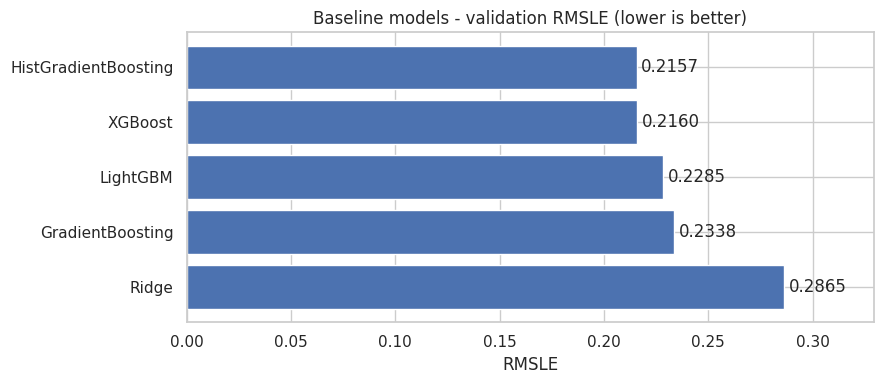

Best baseline: HistGradientBoosting   RMSLE: 0.2157


In [52]:
results_df = (pd.DataFrame({n: {"Train RMSLE": r["train_rmsle"], "Validation RMSLE": r["rmsle"], "Fit time (s)": r["fit_seconds"]}
                            for n, r in results.items()}).T
              .sort_values("Validation RMSLE"))
results_df["Overfit gap"] = results_df["Validation RMSLE"] - results_df["Train RMSLE"]
display(results_df.round(4))

barh_labeled(results_df["Validation RMSLE"], "Baseline models - validation RMSLE (lower is better)",
             "RMSLE", fmt="%.4f", figsize=(9, 4))
print(f"Best baseline: {results_df.index[0]}   RMSLE: {results_df.iloc[0]['Validation RMSLE']:.4f}")

## Hyper-parameter tuning
`RandomizedSearchCV` with 3-fold CV on the training split for **three** models: HistGradientBoosting, LightGBM and XGBoost.
Afterwards we inspect (a) the best parameter values and (b) which parameters actually moved the score.

In [53]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

kf = KFold(n_splits=3, shuffle=True, random_state=SEED)


def param_sensitivity(search):
    """Spearman correlation between each sampled parameter and the CV error (RMSLE).
    Positive = larger value -> larger error (worse); negative = larger value -> lower error (better).
    Bigger |value| = the parameter mattered more."""
    cv = pd.DataFrame(search.cv_results_)
    cv["cv_rmsle"] = -cv["mean_test_score"]
    out = {}
    for p in [c for c in cv.columns if c.startswith("param_")]:
        v = pd.to_numeric(cv[p], errors="coerce")
        if v.notna().sum() > 3:
            out[p.replace("param_model__", "")] = v.corr(cv["cv_rmsle"], method="spearman")
    s = pd.Series(out)
    return s.reindex(s.abs().sort_values(ascending=False).index)


def report_search(name, search):
    print(f"{name}: best CV RMSLE = {-search.best_score_:.4f}")
    display(pd.Series(search.best_params_, name="best value").to_frame())
    sens = param_sensitivity(search)
    barh_labeled(sens, f"{name} - parameter sensitivity (Spearman vs CV RMSLE)", "correlation with CV error",
                 fmt="%.2f", figsize=(8, 4))

### HistGradientBoosting

Fitting 3 folds for each of 100 candidates, totalling 300 fits
HistGradientBoosting: best CV RMSLE = 0.2162


,best value
model__l2_regularization,18.304275
model__learning_rate,0.058659
model__max_depth,9.000000
model__max_iter,1641.000000
model__max_leaf_nodes,62.000000
model__min_samples_leaf,98.000000


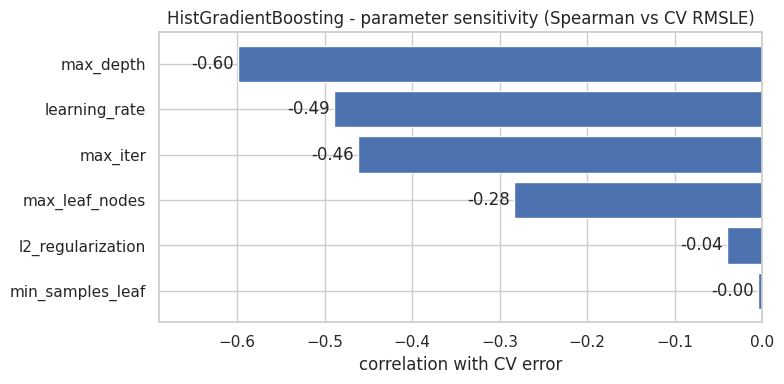

In [54]:
hgb_search = RandomizedSearchCV(
    estimator=baseline_models["HistGradientBoosting"],
    param_distributions={
        "model__max_iter": randint(500, 3000),
        "model__learning_rate": uniform(0.01, 0.11),        # 0.01 .. 0.12
        "model__max_leaf_nodes": randint(15, 64),
        "model__max_depth": randint(4, 10),
        "model__min_samples_leaf": randint(10, 100),
        "model__l2_regularization": uniform(0, 20),
    },
    n_iter=N_ITER_HGB, scoring="neg_root_mean_squared_error", cv=kf, random_state=SEED, n_jobs=-1, verbose=1)
hgb_search.fit(X_train, y_train)
report_search("HistGradientBoosting", hgb_search)
best_hist_gb = hgb_search.best_estimator_

### LightGBM

Fitting 3 folds for each of 100 candidates, totalling 300 fits
LightGBM: best CV RMSLE = 0.2129


,best value
model__colsample_bytree,0.859076
model__learning_rate,0.010026
model__max_depth,13.000000
model__min_child_samples,32.000000
model__min_split_gain,0.003476
model__n_estimators,7575.000000
model__num_leaves,460.000000
model__reg_alpha,0.417411
model__reg_lambda,9.442156
model__subsample,0.735960


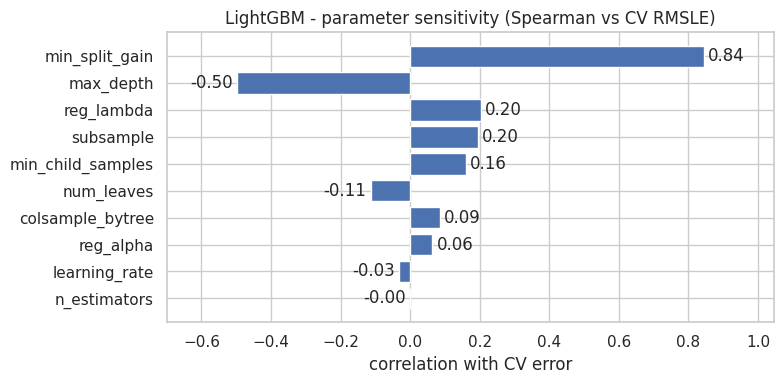

In [55]:
from lightgbm import early_stopping

lgbm_search = RandomizedSearchCV(
    estimator=baseline_models["LightGBM"],
    param_distributions={
        "model__n_estimators": randint(2000, 80v 00),
        "model__learning_rate": uniform(0.01, 0.05),         # 0.01 .. 0.06
        "model__num_leaves": randint(50, 550),
        "model__max_depth": randint(5, 15),
        "model__min_child_samples": randint(30, 150),
        "model__subsample": uniform(0.7, 0.3),               # 0.7 .. 1.0
        "model__colsample_bytree": uniform(0.6, 0.4),        # 0.6 .. 1.0
        "model__reg_alpha": uniform(0.0, 1.0),
        "model__reg_lambda": uniform(5, 20),                 # 5 .. 25
        "model__min_split_gain": uniform(0, 0.5),
    },
    n_iter=N_ITER_LGBM,        # LightGBM has the widest search space -> needs the most samples
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1, random_state=SEED, verbose=1)

# Early stopping needs an evaluation set that is already encoded -> use the (already fitted) baseline preprocessor.
# Known limitation: the validation set is used for early stopping, so the LightGBM validation score is slightly optimistic;
# the CV score printed below does not have this issue and is the fairer number for comparing parameters.
X_val_transformed = baseline_models["LightGBM"].named_steps["prep"].transform(X_val)
lgbm_search.fit(X_train, y_train,
                model__eval_set=[(X_val_transformed, y_val)],
                model__callbacks=[early_stopping(stopping_rounds=400, verbose=False)])
report_search("LightGBM", lgbm_search)
best_lgbm = lgbm_search.best_estimator_

### XGBoost (third tuned model)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost: best CV RMSLE = 0.2131


,best value
model__colsample_bytree,0.710400
model__learning_rate,0.065553
model__max_depth,8.000000
model__min_child_weight,1.000000
model__n_estimators,820.000000
model__reg_alpha,0.772245
model__reg_lambda,4.974314
model__subsample,0.701657


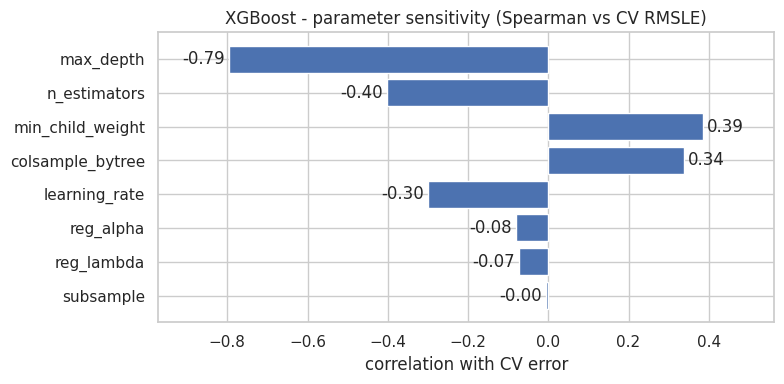

In [56]:
xgb_search = RandomizedSearchCV(
    estimator=baseline_models["XGBoost"],
    param_distributions={
        "model__n_estimators": randint(300, 1000),
        "model__learning_rate": uniform(0.03, 0.12),         # 0.03 .. 0.15
        "model__max_depth": randint(4, 9),
        "model__min_child_weight": randint(1, 20),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__reg_alpha": uniform(0, 1.0),
        "model__reg_lambda": uniform(1, 20),
    },
    n_iter=N_ITER_XGB, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1, random_state=SEED, verbose=1)
xgb_search.fit(X_train, y_train)
report_search("XGBoost", xgb_search)
best_xgb = xgb_search.best_estimator_

## Baseline vs tuned comparison

,Model,RMSLE
0,LightGBM,0.2034
1,XGBoost,0.2062
2,HistGradientBoosting,0.2076


,Baseline,Tuned,Improvement
GradientBoosting,0.2338,NaN,NaN
HistGradientBoosting,0.2157,0.2076,0.0081
LightGBM,0.2285,0.2034,0.0251
Ridge,0.2865,NaN,NaN
XGBoost,0.2160,0.2062,0.0098


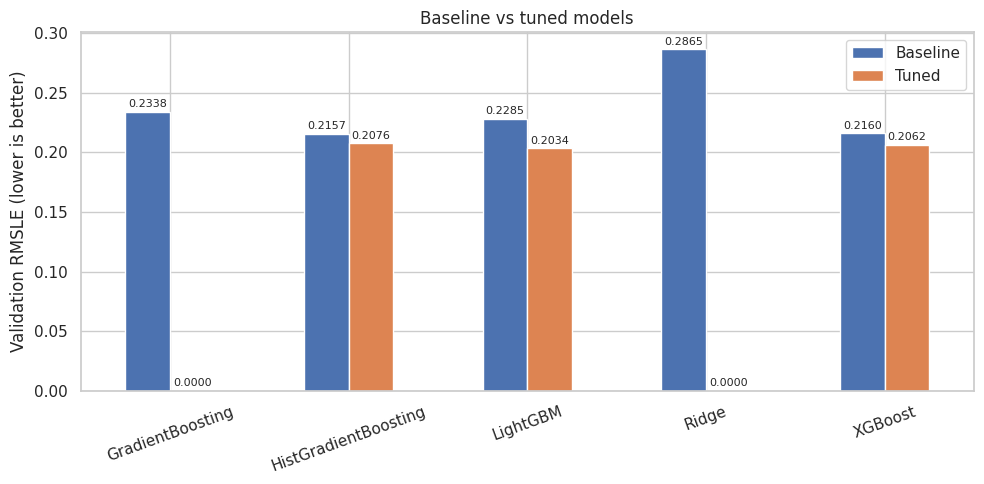

Best tuned model: LightGBM   RMSLE: 0.2034


In [57]:
tuned_models = {"HistGradientBoosting": best_hist_gb, "LightGBM": best_lgbm, "XGBoost": best_xgb}

tuned_results = {name: root_mean_squared_error(y_val, m.predict(X_val)) for name, m in tuned_models.items()}

tuned_results_df = (pd.DataFrame({"Model": list(tuned_results), "RMSLE": list(tuned_results.values())})
                    .sort_values("RMSLE").reset_index(drop=True))
display(tuned_results_df.round(4))

comparison = pd.DataFrame({
    "Baseline": {n: r["rmsle"] for n, r in results.items()},
    "Tuned": pd.Series(tuned_results),
})
comparison["Improvement"] = comparison["Baseline"] - comparison["Tuned"]
display(comparison.round(4))

ax = comparison[["Baseline", "Tuned"]].plot.bar(figsize=(10, 5), rot=20)
for c in ax.containers:
    ax.bar_label(c, fmt="%.4f", fontsize=8, padding=2)
ax.set_ylabel("Validation RMSLE (lower is better)"); ax.set_title("Baseline vs tuned models")
plt.tight_layout(); plt.show()

print(f"Best tuned model: {tuned_results_df.iloc[0]['Model']}   RMSLE: {tuned_results_df.iloc[0]['RMSLE']:.4f}")

# Feature Importance
Which features does the best model rely on? (LightGBM *gain* importance = total loss reduction contributed by splits on that feature.
Gain can favour high-cardinality / continuous features, so treat it as guidance, not proof.)

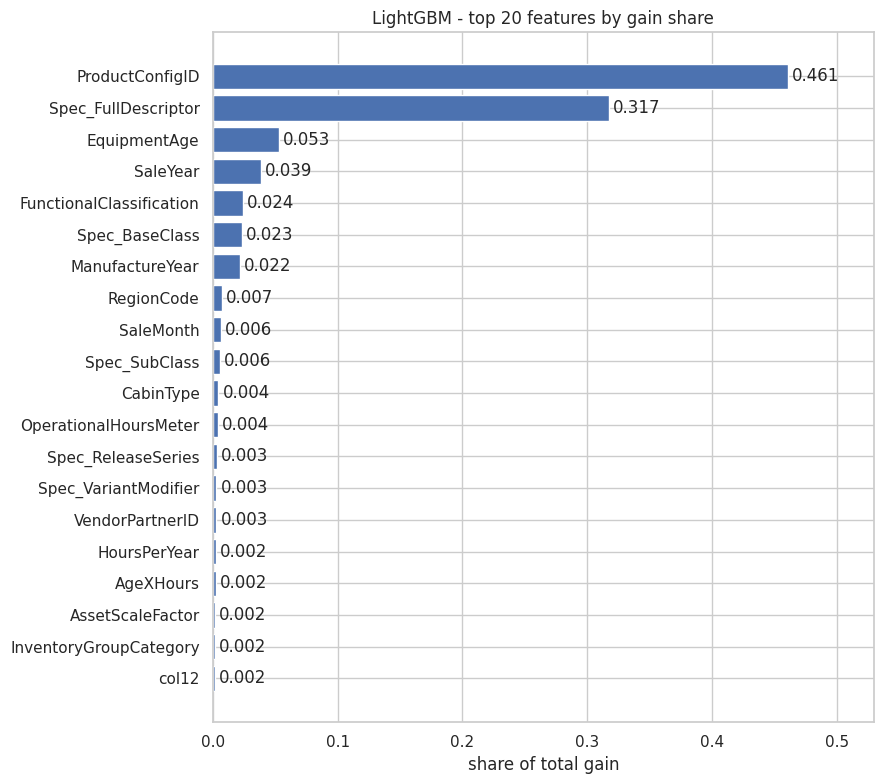

,gain_share,description
ProductConfigID,0.4606,A system-generated code representing the techn...
Spec_FullDescriptor,0.3172,The complete alphanumeric string detailing all...
EquipmentAge,0.0529,(no description in metadata)
SaleYear,0.0386,(no description in metadata)
FunctionalClassification,0.0239,A secondary grouping based on the asset's oper...
Spec_BaseClass,0.0234,"The broad, primary category for the asset's te..."
ManufactureYear,0.0218,The year the asset was originally produced.
RegionCode,0.0072,The specific geographic area or legal jurisdic...
SaleMonth,0.0063,(no description in metadata)
Spec_SubClass,0.0057,"A secondary, more specific tier within the tec..."


Engineered features and their rank:
{'SaleYear': 4, 'SaleMonth': 9, 'SaleQuarter': 30, 'SaleDayOfWeek': 22, 'EquipmentAge': 3, 'LogHours': 32, 'HoursPerYear': 16, 'AgeXHours': 17, 'NumSpecsPresent': 21}
Features contributing < 0.1% of gain each: 50 of 74


In [58]:
lgbm_fitted = best_lgbm.named_steps["model"]
feature_names = best_lgbm.named_steps["prep"].get_feature_names_out()

importance = pd.Series(lgbm_fitted.booster_.feature_importance(importance_type="gain"), index=feature_names)
importance = (importance / importance.sum()).sort_values(ascending=False)

top = importance.head(20)
barh_labeled(top, "LightGBM - top 20 features by gain share", "share of total gain", fmt="%.3f", figsize=(9, 8))

display(pd.DataFrame({"gain_share": top.round(4), "description": [describe_col(f) for f in top.index]}).head(12))
print("Engineered features and their rank:")
print({f: int(importance.index.get_loc(f)) + 1 for f in new_cols if f in importance.index})
print(f"Features contributing < 0.1% of gain each: {(importance < 0.001).sum()} of {len(importance)}")

# Weighted Ensemble
Each tuned model gets weight `1 / RMSLE` (normalised to sum to 1), so better models influence the result more. Blending is done
**in log space** (the space the models predict in and the metric is computed in) for validation *and* test, so the validation score is
a true preview of the test pipeline. Three variants are compared: best single model, equal-weight average, inverse-RMSLE weights.

,Validation RMSLE
Best single (LightGBM),0.2034
Equal-weight average,0.2038
Inverse-RMSLE weighted,0.2037


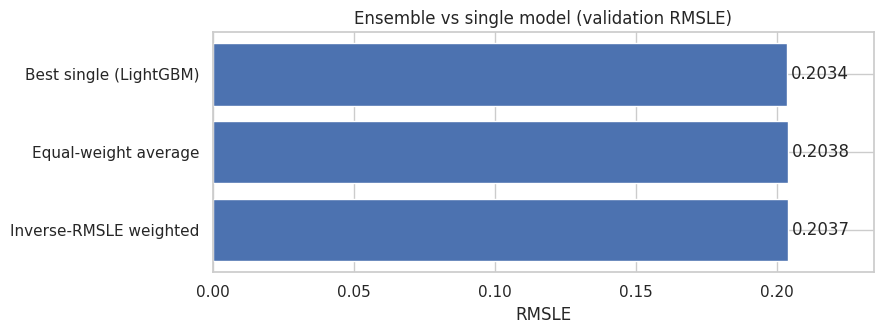

Ensemble weights: {'LightGBM': np.float64(0.3371), 'XGBoost': np.float64(0.3325), 'HistGradientBoosting': np.float64(0.3304)}


In [59]:
ranked_models = tuned_results_df["Model"].tolist()                 # all three, best first
rmsle_arr = np.array([tuned_results[n] for n in ranked_models])
weights = (1 / rmsle_arr) / (1 / rmsle_arr).sum()
weights_dict = dict(zip(ranked_models, weights))

val_log_preds = {n: tuned_models[n].predict(X_val) for n in ranked_models}

ens_weighted = sum(weights_dict[n] * val_log_preds[n] for n in ranked_models)
ens_equal = np.mean([val_log_preds[n] for n in ranked_models], axis=0)

ensemble_summary = pd.Series({
    f"Best single ({ranked_models[0]})": tuned_results[ranked_models[0]],
    "Equal-weight average": root_mean_squared_error(y_val, ens_equal),
    "Inverse-RMSLE weighted": root_mean_squared_error(y_val, ens_weighted),
})
display(ensemble_summary.round(4).to_frame("Validation RMSLE"))
barh_labeled(ensemble_summary, "Ensemble vs single model (validation RMSLE)", "RMSLE", fmt="%.4f", figsize=(9, 3.5))

print("Ensemble weights:", {n: round(w, 4) for n, w in weights_dict.items()})

# Final Training on Train + Validation
The validation set is no longer needed for model selection, so the chosen models are re-fitted on **all** labelled data using the best
parameters. Early stopping is switched off and the number of trees is fixed to the number found during tuning.

In [60]:
X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

final_estimators = {
    "HistGradientBoosting": clone(best_hist_gb).set_params(
        model__max_iter=best_hist_gb.named_steps["model"].n_iter_, model__early_stopping=False),
    "LightGBM": clone(best_lgbm).set_params(
        model__n_estimators=best_lgbm.named_steps["model"].best_iteration_ or best_lgbm.named_steps["model"].n_estimators),
    "XGBoost": clone(best_xgb),
}

final_models = {}
for name in ranked_models:
    t0 = time.time()
    final_models[name] = final_estimators[name].fit(X_full, y_full)
    print(f"{name} re-fitted on {len(X_full)} rows ({time.time() - t0:.0f}s)")

LightGBM re-fitted on 138701 rows (97s)
XGBoost re-fitted on 138701 rows (21s)
HistGradientBoosting re-fitted on 138701 rows (56s)


In [61]:
# blend in LOG space (same as validation), convert to price once at the end
test_log_pred = sum(weights_dict[n] * final_models[n].predict(X_test) for n in ranked_models)
ensemble_pred = np.clip(np.expm1(test_log_pred), 0, None)       # prices cannot be negative

print(f"Min : {ensemble_pred.min():,.2f}")
print(f"Max : {ensemble_pred.max():,.2f}")
print(f"Mean: {ensemble_pred.mean():,.2f}")
print(f"Train TargetValue mean for reference: {train_fe['TargetValue'].mean():,.2f}")

Min : 7,311.33
Max : 138,451.59
Mean: 40,795.72
Train TargetValue mean for reference: 41,521.87


# Submission

In [62]:
submission = pd.DataFrame({
    "TransactionID": test_fe["TransactionID"].values,
    "TargetValue": ensemble_pred,
})

# sanity checks before writing the file
assert len(submission) == len(sample_submission), "row count differs from sample_submission"
assert list(submission.columns) == list(sample_submission.columns), "column names differ from sample_submission"
assert submission["TransactionID"].equals(sample_submission["TransactionID"]) or \
       set(submission["TransactionID"]) == set(sample_submission["TransactionID"]), "TransactionIDs differ"
assert submission["TargetValue"].notna().all(), "NaN in predictions"

submission.to_csv("submission.csv", index=False)
print(f"Rows : {len(submission)}")
submission.head()

Rows : 15000


,TransactionID,TargetValue
0,1139307,72769.729740
1,1139419,78072.260936
2,1139482,29943.829313
3,1139522,17725.984934
4,1139684,12997.354648


# Limitations and next steps
* **Validation:** a random split was used. If the test set lies later in time than train (see the date check above), a time-based split would give a more realistic estimate.
* **Early-stopping leakage:** the LightGBM validation score is slightly optimistic because the validation set also drives early stopping; rely on the CV scores for parameter comparison.
* **Asset history:** if the same `AssetID` appears in train and test (see the identifier investigation), per-asset aggregates of earlier sales would likely be a strong feature.
* **Text columns:** `Spec_FullDescriptor` is high-cardinality text; TF-IDF / length / token features could add signal.
* **Categoricals:** LightGBM / CatBoost native categorical handling is worth comparing against ordinal + target encoding.
* **Feature selection:** features with near-zero gain (see feature importance) can be removed to simplify the model.
* **Run order:** use *Save & Run All* on Kaggle before submitting so every output (plots, tables, scores) is stored in the notebook.

---
# Appendix: course milestones

# Milestones

## Milestone 1

In [63]:
import pandas as pd
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

In [64]:
train_m1 = train.copy()
test_m1 = test.copy()
train_m1.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Extended,Powershuttle,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Florida,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Texas,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


**Q1**

In [65]:
train_m1.shape

(138701, 50)

**Q2**

In [66]:
train_m1["TargetValue"].head()

0    57000.0
1    26500.0
2    21000.0
3    27000.0
4    21500.0
Name: TargetValue, dtype: float64

**Q3**

In [67]:
len(train_m1.select_dtypes(include = ["int64", "float64"]).columns.tolist())

6

**Q4**

In [68]:
missing_count = train_m1.isnull().sum().sort_values(ascending = False)
missing_pct = (missing_count / len(train_m1) )*100

In [69]:
missing_df = pd.DataFrame({"missing_count" : missing_count, "missing_pct" : missing_pct})

In [70]:
missing_df.head()

,missing_count,missing_pct
col19,138635,99.952416
col18,138635,99.952416
col5,128320,92.515555
col4,128320,92.515555
col27,123742,89.214930


**Q5**

In [71]:
missing_df.loc[["OperationalHoursMeter"]]

,missing_count,missing_pct
OperationalHoursMeter,56643,40.838206


**Q6**

In [72]:
train_m1["TargetValue"].median()

35000.0

**Q7**

In [73]:
train_m1["ManufactureYear"].mode()

0    1001
Name: ManufactureYear, dtype: int64

**Q8**

In [74]:
train_m1["TransactionDate"] = pd.to_datetime(train_m1["TransactionDate"])

In [75]:
train_m1["TransactionDate"].min()

Timestamp('1990-01-31 00:00:00')

**Q9**

In [76]:
train_m1["Spec_BaseClass"].nunique()

1249

**Q10**

In [77]:
train_m1["RegionCode"].value_counts().head()

RegionCode
Florida       23460
Texas         18284
California     9525
Washington     6063
Georgia        5240
Name: count, dtype: int64

**Q11**

In [78]:
train_m1[(train_m1["RegionCode"] == "Florida") & (train_m1["TargetValue"])]["TargetValue"].mean()

np.float64(45007.54262574595)

**Q12**

In [79]:
train_m1["UtilizationTier"].value_counts()

UtilizationTier
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

**Q13**

In [80]:
train.corr(numeric_only = True)

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
TransactionID,1.000000,-0.012093,0.373844,0.129477,0.065617,0.008129
TargetValue,-0.012093,1.000000,-0.238719,0.057265,0.204439,0.001994
AssetID,0.373844,-0.238719,1.000000,0.154943,-0.029941,0.003505
ProductConfigID,0.129477,0.057265,0.154943,1.000000,-0.009438,-0.013551
ManufactureYear,0.065617,0.204439,-0.029941,-0.009438,1.000000,-0.008256
OperationalHoursMeter,0.008129,0.001994,0.003505,-0.013551,-0.008256,1.000000


In [81]:
train.corr(numeric_only = True)["TargetValue"].sort_values()

AssetID                 -0.238719
TransactionID           -0.012093
OperationalHoursMeter    0.001994
ProductConfigID          0.057265
ManufactureYear          0.204439
TargetValue              1.000000
Name: TargetValue, dtype: float64

**Q14**

In [82]:
train_m1["FunctionalClassification"].value_counts().head(1)

FunctionalClassification
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons    11158
Name: count, dtype: int64

## Milestone 2

In [83]:
train_m2 = train.copy()
test_m2 = test.copy()

In [84]:
train_m2["TransactionDate"] = pd.to_datetime(train_m2["TransactionDate"])

In [85]:
train_m2["TransactionYear"]  = train_m2["TransactionDate"].dt.year

In [86]:
train_m2["TransactionQuarter"] = train_m2["TransactionDate"].dt.quarter

In [87]:
train_m2["AssetAge"] = train_m2["TransactionYear"] - train_m2["ManufactureYear"]

In [88]:
train_m2["DescriptionLength"] = train_m2["Spec_FullDescriptor"].str.len()

In [89]:
train_m2["HasOperationHours"] = train_m2["OperationalHoursMeter"].notna().astype(int)

In [90]:
train_m2["HasVariantModifier"] = train_m2["Spec_VariantModifier"].notna().astype(int)

**Q1**

In [91]:
train_m2["AssetAge"].mode()

0    5
Name: AssetAge, dtype: int64

**Q2**

In [92]:
train_m2[["TransactionQuarter", "TargetValue"]]

,TransactionQuarter,TargetValue
0,1,57000.0
1,4,26500.0
2,3,21000.0
3,4,27000.0
4,3,21500.0
...,...,...
138696,1,10000.0
138697,1,10500.0
138698,1,12500.0
138699,1,10000.0


In [93]:
train_m2.groupby("TransactionQuarter")["TargetValue"].mean().sort_values(ascending = False)

TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64

**Q3**

In [94]:
train_m2["DescriptionLength"].max()

19

**Q4**

In [95]:
train_m2["HasOperationHours"].value_counts()

HasOperationHours
1    82058
0    56643
Name: count, dtype: int64

**Q5**

In [96]:
x = (train_m2.notnull().sum().sum())/((train_m2.notnull().sum().sum()) + (train_m2.isnull().sum().sum()))*100

In [97]:
x

np.float64(57.26864158977122)

**Q6**

In [98]:
train_m2["ManufactureYear"].mean().round(2)

np.float64(1891.64)

In [99]:
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [100]:
columns = ["RegionCode", "CabinType", "UtilizationTier"]

preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(drop = "first" , sparse_output = False), columns)
], remainder = "passthrough" , verbose_feature_names_out = False).set_output(transform = "pandas")


train_encoded = preprocessor.fit_transform(train_m2)

**Q7**

In [101]:
train_encoded.shape[1]-train_m2.shape[1]

54

**Q8**

In [102]:
abs(train_m2.corr(numeric_only = True)["TargetValue"]).sort_values(ascending = False)

TargetValue              1.000000
AssetID                  0.238719
HasVariantModifier       0.217434
AssetAge                 0.204698
ManufactureYear          0.204439
DescriptionLength        0.061502
ProductConfigID          0.057265
TransactionQuarter       0.034442
TransactionYear          0.024497
TransactionID            0.012093
HasOperationHours        0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64

**Q9**

In [103]:
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

In [104]:
scaling_preprocessor = ColumnTransformer([
    ("impute_scale", Pipeline([
        ("impute", SimpleImputer(strategy = "mean")),
        ("scaler", StandardScaler())
    ]),["ManufactureYear" , "OperationalHoursMeter", "AssetAge"])
],  remainder = "passthrough",  verbose_feature_names_out = False).set_output(transform = "pandas")


scale_impute = scaling_preprocessor.fit_transform(train_m2)

In [105]:
scale_impute.head()

,ManufactureYear,OperationalHoursMeter,AssetAge,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30,TransactionYear,TransactionQuarter,DescriptionLength,HasOperationHours,HasVariantModifier
0,0.343200,0.004017,-0.351098,1139309,57000.0,117665,88,ACH138,GTX,Low,2005-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,2005,1,6,1,0
1,0.369259,-0.188378,-0.364119,1139316,26500.0,1001282,4616,ACH138,GTX,Low,2009-12-18,310G,310,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Extended,Powershuttle,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009,4,4,1,0
2,0.333427,0.325298,-0.341331,1139317,21000.0,772709,1948,ACH138,GTX,High,2005-08-26,790ELC,790,E,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Florida,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,2005,3,6,1,1
3,0.359487,0.015332,-0.364119,1139322,27000.0,902010,3550,ACH138,GTX,High,2006-11-17,416D,416,D,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006,4,4,1,0
4,0.382289,-0.197970,-0.373886,1139333,21500.0,1036259,36014,ACH138,GTX,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Texas,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,2010,3,6,1,0


In [106]:
from sklearn.model_selection import train_test_split 

In [107]:
X = scale_impute[["ManufactureYear", "AssetAge"]]
y = scale_impute["TargetValue"]


X_train_m2, X_val_m2 ,y_train_m2, y_val_m2 = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [108]:
X_train_m2.shape

(110960, 2)

**Q9**

In [109]:
X_train_m2.shape

(110960, 2)

**Q10**

In [110]:
X_val_m2.shape

(27741, 2)

**Q11**

In [111]:
from sklearn.linear_model import LinearRegression

In [112]:
model = LinearRegression()

model.fit(X_train_m2 ,y_train_m2)



LinearRegression()

In [113]:
y_pred = model.predict(X_val_m2)


In [114]:
from sklearn.metrics import r2_score, root_mean_squared_log_error
r2_score(y_val_m2, y_pred)


0.041826810984318286

## Milestone 3

In [115]:
# Q1

train_m3 = train.copy()
test_m3 = test.copy()

In [116]:
train_m3["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

In [117]:
train_m3["TransactionYear"] = train_m3["TransactionDate"].dt.year

In [118]:
train_m3["TransactionYear"].mode()

0    2010
Name: TransactionYear, dtype: int32

In [119]:
# q2

import numpy as np
train_m3["ManufactureYear"] = train_m3["ManufactureYear"].replace([1001, 1000] , np.nan)


train_m3["AssetAge"] = train_m3["TransactionYear"] - train_m3["ManufactureYear"]

In [120]:
train_m3["AssetAge"].median()

8.0

In [121]:
# Q3


train_m3["HoursPerYear"] = train_m3["OperationalHoursMeter"] / train_m3["AssetAge"]

In [122]:
train_m3["HoursPerYear"].median()

320.4415584415584

In [123]:
# Q4


missing_df[missing_df["missing_pct"] > 80].shape

(15, 2)

In [124]:
# Q5


# median

In [125]:
# Q6

train_m3["CabinType"].value_counts()
train_m3["CabinType"].isnull().sum()

np.int64(0)

In [126]:
# Q7

from sklearn.model_selection import train_test_split


X = train_m3.drop(["TargetValue"], axis = 1)
y = train_m3["TargetValue"]


X_train_m3, X_val_m3, y_train_m3, y_val_m3 = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [127]:
X_train_m3.shape

(110960, 52)

In [128]:
# Q10

train_m3["UtilizationTier"].value_counts()

UtilizationTier
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

In [129]:
# Q11

train_m3["TargetValue"] = np.log1p(train["TargetValue"])
train_m3["TargetValue"].std()

0.6709620692098283

## Milestone 4

**Q1**

In [130]:
train_m4 = train.copy()
test_m4 = test.copy()

In [131]:
train_m4["UtilizationTier"].isnull().sum()

np.int64(88226)

In [132]:
train_m4["UtilizationTier"] = train_m4["UtilizationTier"].replace(np.nan , "Unknown")

In [133]:
from sklearn.model_selection import train_test_split 

In [134]:
columns = ["UtilizationTier","DrivetrainType","CabinType", "AssetScaleFactor", "ManufactureYear", "OperationalHoursMeter", "Spec_FullDescriptor" , "RegionCode" , "FunctionalClassification"]

train_m4 = train[columns].copy()

In [135]:
train_m4["PriceBand"] = pd.qcut(train["TargetValue"], q =5, labels = False)

**part A**

In [136]:
X = train_m4.drop(["PriceBand"], axis = 1)
y = train_m4["PriceBand"]

In [137]:
X_train , X_val , y_train , y_val = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify  = y)

In [138]:
train_counts = (y_train.value_counts().sort_index().to_numpy())

In [139]:
val_counts = (y_val.value_counts().sort_index().to_numpy())

In [140]:
train_counts

array([20186, 19621, 18667, 19539, 19077])

In [141]:
val_counts

array([8651, 8410, 8000, 8374, 8176])

**Part B**

In [142]:
X_train , X_val , y_train , y_val = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify  = None)

In [143]:
train_counts_ns = (y_train.value_counts().sort_index().to_numpy())

In [144]:
val_counts_ns = (y_val.value_counts().sort_index().to_numpy())

In [145]:
train_counts_ns

array([20105, 19760, 18544, 19501, 19180])

In [146]:
val_counts_ns

array([8732, 8271, 8123, 8412, 8073])

**Part C**

In [147]:
val_prop_strat = val_counts / val_counts.sum()
val_prop_non = val_counts_ns / val_counts_ns.sum()

In [148]:
abs_diff = np.abs(val_prop_strat - val_prop_non)

In [149]:
max_diff = round(abs_diff.max(), 4)

In [150]:
print("Maximum absolute difference:", max_diff)

Maximum absolute difference: 0.0033


**Q2**

In [151]:
Cat_cols =  ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"] 

In [152]:
Num_cols =  ["ManufactureYear", "OperationalHoursMeter"] 

In [153]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [154]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [155]:
col_pipeline  = Pipeline([
    ("impute", SimpleImputer(strategy = "most_frequent")),
    ("encode", OneHotEncoder(handle_unknown = "ignore", sparse_output = True))
])

num_pipeline = Pipeline([
    ("impute" , SimpleImputer(strategy = "mean")),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("col" , col_pipeline, Cat_cols),
    ("num", num_pipeline, Num_cols)
], remainder = "drop", verbose_feature_names_out = False)

In [156]:
X_train_processed = preprocessor.fit_transform(X_train)

In [157]:
X_val_processed = preprocessor.transform(X_val)

In [158]:
X_train_processed.sum()

np.float64(388359.99999999994)

**Q3**

In [159]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [160]:
model = RandomForestRegressor(random_state = 42)

param = {
    "n_estimators" : [50, 100, 200],
    "max_depth" : [5, 10, 15]
}

In [161]:
search = RandomizedSearchCV(
    estimator = model,
    param_distributions = param,
    n_iter = 5,
    cv = 3,
    random_state = 42,
    n_jobs = -1,
)

tuned_RF = search.fit(X_train_processed, y_train)

In [162]:
tuned_RF

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42)

In [163]:
tuned_RF.best_params_
tuned_RF.best_estimator_

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

**Q4**

In [164]:
from sklearn.ensemble import AdaBoostRegressor

AdB_model = AdaBoostRegressor(n_estimators = 50, random_state = 42)


In [165]:
AdB_model.fit(X_train_processed, y_train)

AdaBoostRegressor(random_state=42)

In [166]:
estimator_errors = AdB_model.estimator_errors_

In [167]:
variance = np.var(estimator_errors)

In [168]:
result = round(variance, 4)


In [169]:
print("Estimator Errors:", estimator_errors)
print("Variance:", result)

Estimator Errors: [0.24668691 0.28359489 0.31742536 0.35843108 0.3753275  0.34735012
 0.3749043  0.38881925 0.38154815 0.39544758 1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]
Variance: 0.0687


**Q5**

In [170]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

model.fit(X_train_processed, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [171]:
importances = pd.DataFrame(model.feature_importances_)

In [172]:
importances.sort_values(by = 0)

,0
5,0.000000
3,0.000061
4,0.000192
0,0.000516
2,0.000919
6,0.001921
13,0.002572
11,0.002763
9,0.002973
15,0.005127


**Q6**

In [173]:
N = X_train_processed.shape[1] 

In [174]:
from sklearn.neural_network import MLPRegressor

In [175]:
model = MLPRegressor(hidden_layer_sizes = (128, 64, 32))

In [176]:
total_weights = N * 128 + 128 * 64 + 64 * 32 + 32 * 1

In [177]:
total_weights

13088

**Q7**

In [178]:
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    batch_size=32,
    max_iter=5,
    random_state=42
)

In [179]:
model.fit(X_train_processed, y_train)

MLPRegressor(batch_size=32, hidden_layer_sizes=(128, 64, 32), max_iter=5,
             random_state=42)

In [180]:
loss = round(model.loss_, 4)
loss

np.float64(0.4603)

**Q8**

In [181]:
from sklearn.metrics import mean_absolute_error

In [182]:
model_a = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=0.0001,
    max_iter=5,
    random_state=42
)

In [183]:
model_b = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=1.0,
    max_iter=5,
    random_state=42
)

In [184]:
model_a.fit(X_train_processed, y_train)
model_b.fit(X_train_processed, y_train)

MLPRegressor(alpha=1.0, max_iter=5, random_state=42)

In [185]:
pred_a = model_a.predict(X_train_processed)
pred_b = model_b.predict(X_train_processed)

In [186]:
mae_a = mean_absolute_error(y_train, pred_a)
mae_b = mean_absolute_error(y_train, pred_b)

In [187]:
mae_diff = round(abs(mae_a - mae_b), 4)

In [188]:
print("MAE (alpha=0.0001):", round(mae_a, 4))
print("MAE (alpha=1.0):", round(mae_b, 4))
print("Absolute Difference:", mae_diff)

MAE (alpha=0.0001): 0.8178
MAE (alpha=1.0): 0.8509
Absolute Difference: 0.0331


**Q9**

In [189]:
y_pred = model.predict(X_val_processed)

In [190]:
val_mae = mean_absolute_error(y_val, y_pred)

In [191]:
print("Validation MAE:", round(val_mae, 4))

Validation MAE: 0.757
